# Drug Related Mortality Clustering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kmedoids

from nltk.corpus import stopwords
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram
from kmodes.kmodes import KModes
from sklearn.metrics import silhouette_samples

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)

## Data Loading

In [2]:
df = pd.read_csv('data/Accidental_Drug_Related_Deaths_2012-2024.csv')
df.shape
df.head()

,Date,Date Type,Age,Sex,Race,Ethnicity,Residence City,Residence County,Residence State,Injury City,Injury County,Injury State,Injury Place,Description of Injury,Death City,Death County,Death State,Location,Location if Other,Cause of Death,Manner of Death,Other Significant Conditions,Heroin,Heroin death certificate (DC),Cocaine,Fentanyl,Fentanyl Analogue,Oxycodone,Oxymorphone,Ethanol,Hydrocodone,Benzodiazepine,Methadone,Meth/Amphetamine,Amphet,Tramad,Hydromorphone,Morphine (Not Heroin),Xylazine,Gabapentin,Opiate NOS,Heroin/Morph/Codeine,Other Opioid,Any Opioid,Other,ResidenceCityGeo,InjuryCityGeo,DeathCityGeo
0,01/02/2023,Date of death,65.0,Male,White,"No, not Spanish/Hispanic/Latino",BRIDGEPORT,FAIRFIELD,CT,BRIDGEPORT,FAIRFIELD,NaN,Other,Substance use,NaN,NaN,NaN,NaN,NaN,Acute Intoxication by the Combined Effects of Fentanyl and Cocaine,Accident,NaN,NaN,NaN,Y,Y,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Y,NaN,"BRIDGEPORT, CT\n(41.179195, -73.189476)","BRIDGEPORT, CT\n(41.179195, -73.189476)","CT\n(41.57350273, -72.738305908)"
1,01/18/2023,Date of death,42.0,Male,White,"No, not Spanish/Hispanic/Latino",WATERBURY,NEW HAVEN,CT,FARMINGTON,HARTFORD,CT,Home,Ethanol and Fentanyl Use,NaN,NaN,NaN,NaN,NaN,Combined Effects of Fentanyl and Ethanol Toxicity,Accident,NaN,NaN,NaN,NaN,Y,NaN,NaN,NaN,Y,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Y,NaN,"WATERBURY, CT\n(41.5542609, -73.0430692)","FARMINGTON, CT\n(41.726536, -72.8250564)","CT\n(41.57350273, -72.738305908)"
2,01/26/2022,Date of death,34.0,Male,White,NaN,BROOKFIELD,FAIRFIELD,CT,BROOKFIELD,FAIRFIELD,CT,Home,Substance Abuse,NaN,NaN,NaN,Decedent’s Home,NaN,"Acute Intoxication due to the Combined Effects of Fentanyl, Heroin, Xylazine and Clonazepam",Accident,NaN,Y,NaN,NaN,Y,NaN,NaN,NaN,NaN,NaN,Y,NaN,NaN,NaN,NaN,NaN,NaN,Y,NaN,NaN,Y,NaN,Y,NaN,"BROOKFIELD, CT\n(41.46736000000004, -73.39825999999994)","BROOKFIELD, CT\n(41.46736000000004, -73.39825999999994)","CT\n(41.57350273000003, -72.73830590799997)"
3,02/04/2023,Date of death,34.0,Male,White,NaN,NaN,NaN,NaN,NEW HAVEN,NEW HAVEN,CT,Other,Substance Use,NaN,NaN,NaN,NaN,NaN,Acute Fentanyl Intoxication with Recent Cocaine Use,Accident,NaN,NaN,NaN,Y,Y,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Y,NaN,"CT\n(41.57350273, -72.738305908)","NEW HAVEN, CT\n(41.3082517, -72.9241605)","CT\n(41.57350273, -72.738305908)"
4,02/18/2022,Date of death,43.0,Male,White,NaN,NORWICH,NEW LONDON,CT,NORWICH,NEW LONDON,CT,Public Recreation Area,Drug Use,NaN,NaN,NaN,Other (Specify),Mohegan Park,Acute Cocaine and Fentanyl Intoxication,Accident,NaN,NaN,NaN,Y,Y,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Y,NaN,"NORWICH, CT\n(41.526760000000024, -72.07567999999998)","NORWICH, CT\n(41.526760000000024, -72.07567999999998)","CT\n(41.57350273000003, -72.73830590799997)"


## Data Exploration & Cleaning
### Demographics

In [3]:
# Copy data to preserve original in case of error
df_clean = df.copy()

# Extract year from date column
df_clean['Year'] = pd.to_datetime(df_clean['Date']).dt.year

In [4]:
print(df[['Age', 'Sex', 'Race', 'Ethnicity']].isnull().sum())
df[['Sex', 'Race', 'Ethnicity']].nunique()

Age             2
Sex             9
Race           66
Ethnicity    9528
dtype: int64


Sex           4
Race         23
Ethnicity    15
dtype: int64

In [5]:
# Correct extra space in column name
df_clean = df_clean.rename(columns={'Other Significant Conditions ': 'Other Significant Conditions'})
# Drop 2 rows with a null age
df_clean = df_clean.dropna(subset=['Age'])


In [6]:
print(df_clean['Sex'].value_counts(dropna=False))
print(df_clean['Race'].value_counts(dropna=False))


Sex
Male       9570
Female     3380
NaN           8
Unknown       2
X             1
Name: count, dtype: int64
Race
White                                                       10801
Black or African American                                    1027
Black                                                         809
NaN                                                            65
Unknown                                                        63
Other                                                          52
Other (Specify)                                                46
Asian Indian                                                   31
Asian, Other                                                   24
Other Asian                                                    12
American Indian or Alaska Native                                6
Asian/Indian                                                    5
Asian                                                           4
white                      

In [7]:
df_clean['Ethnicity'].value_counts(dropna=False)

Ethnicity
NaN                                             9526
No, not Spanish/Hispanic/Latino                 1409
Hispanic                                         972
Yes, other Spanish/Hispanic/Latino               307
Spanish/Hispanic/Latino                          267
Other Spanish/Hispanic/Latino                    254
Yes, Puerto Rican                                 85
Not Spanish/Hispanic/Latino                       56
Yes, Other Spanish/Hispanic/Latino (Specify)      26
Unknown                                           24
Puerto Rican                                      19
Yes, Mexican, Mexican American, Chicano            8
Mexican, Mexican American, Chicano                 4
Cuban                                              2
Yes, Cuban                                         1
n                                                  1
Name: count, dtype: int64

In [8]:
# Cleaning the three demomgraphic columns
df_clean['Sex'] = df_clean['Sex'].replace([np.nan, 'X'], 'Unknown')

df_clean['Race'] = df_clean['Race'].replace('white', 'White')
df_clean['Race'] = df_clean['Race'].replace('Black', 'Black or African American')
df_clean['Race'] = df_clean['Race'].replace(np.nan, 'Unknown')
df_clean.loc[df_clean['Race'].str.contains('Asian|Chinese|Korean|Japanese', na=False), 'Race'] = 'Asian'
df_clean.loc[df_clean['Race'].str.contains('Hawaiian|Native American', na=False), 'Race'] = 'American Indian or Alaska Native'
df_clean.loc[df_clean['Race'].str.contains('Other|Lenape', na=False), 'Race'] = 'Other'

df_clean.loc[df_clean['Ethnicity'].str.contains('Hispanic|Spanish|Puerto|Mexican|Cuban', na=False), 'Ethnicity'] = 'Spanish/Hispanic/Latino'
df_clean.loc[df_clean['Ethnicity'].str.contains('Not|No|^n$', na=False), 'Ethnicity'] = 'Not Spanish/Hispanic/Latino'
df_clean['Ethnicity'] = df_clean['Ethnicity'].fillna('Unknown')

In [9]:
df_clean['Race'].value_counts()

Race
White                               10804
Black or African American            1836
Unknown                               128
Other                                 104
Asian                                  81
American Indian or Alaska Native        8
Name: count, dtype: int64

In [10]:
df_clean['race_ethnicity'] = df_clean['Race'].copy()
df_clean.loc[df_clean['Race'].str.contains('Asian|Indian', na=False), 'race_ethnicity'] = 'Other'
df_clean.loc[df_clean['Race'].str.contains('Black', na=False), 'race_ethnicity'] = 'Black'
df_clean.loc[df_clean['Ethnicity'] == 'Spanish/Hispanic/Latino', 'race_ethnicity'] = 'Hispanic'


In [11]:
df_clean['race_ethnicity'].value_counts()

race_ethnicity
White       7906
Hispanic    3410
Black       1432
Unknown      108
Other        105
Name: count, dtype: int64

### Incident Related Columns: Location of Injury & Death

In [12]:
df_clean[['Injury Place', 'Location', 'Location if Other', 'Manner of Death', 'Cause of Death', 'Other Significant Conditions']].nunique()

Injury Place                      99
Location                          16
Location if Other                543
Manner of Death                    6
Cause of Death                  8186
Other Significant Conditions     428
dtype: int64

In [13]:
df_clean['Manner of Death'].value_counts(dropna=False)

Manner of Death
Accident     12921
Pending         14
accident        14
NaN              9
Acciddent        1
ACCIDENT         1
Natural          1
Name: count, dtype: int64

In [14]:
# Correcting typos and case
df_clean.loc[df_clean['Manner of Death'].str.contains('Acci', case=False, na=False), 'Manner of Death'] = 'Accident'

In [15]:
df_clean['Location'].value_counts(dropna=False)

Location
Residence                     4798
Hospital                      2336
NaN                           2330
Other                         1559
Decedent’s Home                776
Hospital - ER/Outpatient       401
Other (Specify)                362
Hospital - Inpatient           246
Hospital - Dead On Arrival      81
Decedent's Home                 52
Nursing Home                     9
Convalescent Home                3
Hospice                          3
Assisted Living                  2
Hiospital                        1
Hospice Facility                 1
Shelter                          1
Name: count, dtype: int64

In [16]:
# Consolidating location into logical categories
df_clean['death_place_cat'] = df_clean['Location'].copy()
df_clean.loc[df_clean['death_place_cat'].str.contains('Residence|Decedent',case=False, na=False), 'death_place_cat'] = 'Residence'
df_clean.loc[df_clean['death_place_cat'].str.contains('Hospital|Hiospital', case=False, na=False), 'death_place_cat'] = 'Hospital'
df_clean.loc[df_clean['death_place_cat'].str.contains('Nursing|Convalescent|Hospice|Assisted', case=False, na=False), 'death_place_cat'] = 'LTC/Hospice'
df_clean.loc[df_clean['death_place_cat'].str.contains('Other|Shelter', case=False, na=False), 'death_place_cat'] = 'Other'

In [17]:
df_clean['Injury Place'].value_counts()

Injury Place
Residence                                         6187
Home                                              2423
Other                                              968
Hotel or Motel                                     491
Other Specified Place                              433
Unknown                                            308
Residential Building                               286
Unspecified Place                                  180
In Vehicle                                         149
House                                              134
Apartment                                          109
Other, Other Outdoor Area                           90
Automobile                                          76
Parking Lot                                         61
Other, Residential Institution                      57
Halfway House                                       52
Other building                                      38
Restaurant                                          

In [18]:
# Consolidating like entries into logical categories
df_clean['injury_place_cat'] = df_clean['Injury Place'].copy()
df_clean.loc[df_clean['injury_place_cat'].str.contains('Vehicle|Automobile|^Car$|car in', case=False, na=False), 'injury_place_cat'] = 'Vehicle'
df_clean.loc[df_clean['injury_place_cat'].str.contains('Street|Highway|Sidewalk|Roadway|Alleyway|Railroad|Parking|Field|Forest|Beach|Campground|Lake|River|Cemetery|Vacant Lot|Outdoor|Park|Marina|Recreation', case=False, na=False), 'injury_place_cat'] = 'Public Outdoors'
df_clean.loc[df_clean['injury_place_cat'].str.contains('Hotel|Motel', case=False, na=False), 'injury_place_cat'] = 'Hotel/Motel'
df_clean.loc[df_clean['injury_place_cat'].str.contains('Residential|Residence|Home|House|Apartment|Farm|Porch|Yard|Backyard|Driveway|Shed|Garage$', case=False, na=False), 'injury_place_cat'] = 'Residence'
df_clean.loc[df_clean['injury_place_cat'].str.contains('Nursing|Assisted Living|Hospital|Health Care', case=False, na=False), 'injury_place_cat'] = 'Hospital LTC'
df_clean.loc[df_clean['injury_place_cat'].str.contains('Detox|Halfway|Sober|Rehab|Rest', case=False, na=False), 'injury_place_cat'] = 'Rehab Recovery'
df_clean.loc[df_clean['injury_place_cat'].str.contains('Industrial|Warehouse|Construction', case=False, na=False), 'injury_place_cat'] = 'Industrial'
df_clean.loc[df_clean['injury_place_cat'].str.contains('Shopping|Convenience|Casino|Bus|Train|Police|Service|Office|Restaurant|Bar|Gas|Store', case=False, na=False), 'injury_place_cat'] = 'Commercial'
df_clean.loc[df_clean['injury_place_cat'].str.contains('Institutional|School|Penal|University', case=False, na=False), 'injury_place_cat'] = 'Institution'
df_clean.loc[df_clean['injury_place_cat'].str.contains('Building|Church', case=False, na=False), 'injury_place_cat'] = 'Other Building'
df_clean.loc[df_clean['injury_place_cat'].str.contains('Unknown|Multiple|Unspecified', case=False, na=False), 'injury_place_cat'] = 'Unknown'
df_clean.loc[df_clean['injury_place_cat'].str.contains('Stairs|Indoor', case=False, na=False), 'injury_place_cat'] = 'Other Indoor Area'


In [19]:
df_clean[['death_place_cat', 'injury_place_cat', 'Manner of Death']].nunique()

death_place_cat      4
injury_place_cat    14
Manner of Death      3
dtype: int64

### Comorbid Conditions

In [20]:
print(f'Unique Conditions: {df_clean['Other Significant Conditions'].nunique()}')
df_clean['Other Significant Conditions'].value_counts().head(20)

Unique Conditions: 428


Other Significant Conditions
Recent Cocaine Use                                                  211
Hypertensive and Atherosclerotic Cardiovascular Disease             174
Recent cocaine use                                                   74
Atherosclerotic and Hypertensive Cardiovascular Disease              46
Hypertensive Cardiovascular Disease                                  44
Hypertensive And Atherosclerotic Cardiovascular Disease              43
Hypertensive and atherosclerotic cardiovascular disease              42
Cardiac Hypertrophy                                                  31
Atherosclerotic Cardiovascular Disease                               28
Acute Cocaine Intoxication                                           21
Obesity                                                              18
Hypertensive cardiovascular disease                                  12
Acute cocaine intoxication                                           10
RECENT COCAINE USE                 

In [21]:
stop_words = set(stopwords.words('english'))
stop_words.update(['disease', 'substance', 'use', 'recent', 'acute', 'combined', 'abuse', 'effects'])

conditions = df_clean['Other Significant Conditions'].str.lower()
conditions = conditions.dropna().str.split(r'[,;\s]+', regex=True).explode()
conditions[~conditions.isin(stop_words)].value_counts().head(30)

Other Significant Conditions
cardiovascular      548
hypertensive        483
cocaine             433
atherosclerotic     427
intoxication        121
chronic             119
obesity              92
hypertrophy          63
cardiac              62
diabetes             53
pulmonary            48
mellitus             44
arteriosclerotic     36
fentanyl             33
methadone            28
emphysema            24
obstructive          24
coronary             19
cirrhosis            18
alcohol              17
artery               17
alcoholism           16
hypertension         15
toxicity             14
ketoacidosis         14
infection            12
oxycodone            12
due                  12
cardiomegaly         12
hepatic              11
Name: count, dtype: int64

In [22]:
# Create new columns for comorbid conditions based on Other Significant Conditions column
df_clean['cardiovascular_disease'] = df_clean['Other Significant Conditions'].str.contains('Cardio|Cardiac|Hyperten|Atherosclerotic|Heart|Coronary|ASCVD|Thromboembo|Atrial|Ventricular|Carditis', case=False, na=False).astype(int)
df_clean['obesity'] = df_clean['Other Significant Conditions'].str.contains('obesity', case=False, na=False).astype(int)
df_clean['diabetes'] = df_clean['Other Significant Conditions'].str.contains('Diabet', case=False, na=False).astype(int)
df_clean['chronic_pulmonary'] = df_clean['Other Significant Conditions'].str.contains('Obstructive|Emphysema|Asthma|Lung|CIOPD|COPD', case=False, na=False).astype(int)
df_clean['acute_pulmonary'] = df_clean['Other Significant Conditions'].str.contains('COVID|Pneumonia|Corona', case=False, na=False).astype(int)
df_clean['total_pulmonary'] = df_clean['Other Significant Conditions'].str.contains('Obstructive|Emphysema|Asthma|Lung|CIOPD|COPD|COVID|Pneumonia|Corona', case=False, na=False).astype(int)
df_clean['renal_disease'] = df_clean['Other Significant Conditions'].str.contains('Renal|Kidney', case=False, na=False).astype(int)
df_clean['gi_disease'] = df_clean['Other Significant Conditions'].str.contains('Cirrhosis|Hepatic|Liver|Duodenal|Pancreat', case=False, na=False).astype(int)
df_clean['alcoholism'] = df_clean['Other Significant Conditions'].str.contains('Alcoholism|Ethanolism', case=False, na=False).astype(int)
df_clean['cancer'] = df_clean['Other Significant Conditions'].str.contains('Carcinoma|Myeloma', case=False, na=False).astype(int)


In [23]:
comorbidities = ['cardiovascular_disease', 'obesity', 'diabetes', 'chronic_pulmonary', 'acute_pulmonary', 'total_pulmonary', 'renal_disease', 'gi_disease', 'cancer', 'alcoholism']
print(df_clean[comorbidities].sum())
has_condition = df_clean['Other Significant Conditions'].notna()
has_category = df_clean[comorbidities].any(axis=1)
uncategorized = df_clean[has_condition & ~has_category]

print(f'\nUncategorized: {len(uncategorized)}')
uncategorized[~uncategorized['Other Significant Conditions'].str.contains('Intoxication|Use|Toxicity|Cocaine', case=False, na=False)]['Other Significant Conditions'].value_counts(50)

cardiovascular_disease    685
obesity                    92
diabetes                   62
chronic_pulmonary          65
acute_pulmonary            45
total_pulmonary           109
renal_disease              13
gi_disease                 26
cancer                      6
alcoholism                 21
dtype: int64

Uncategorized: 504


Other Significant Conditions
Seizure Disorder                     0.250000
Systemic Sarcoidosis                 0.166667
Hypothermia                          0.083333
Hidradenitis Suppurativa             0.083333
Drowning                             0.083333
Pheochromocytoma                     0.083333
MULT DRUGS                           0.083333
Opiate                               0.083333
Terminal aspiration of food bolus    0.083333
Name: proportion, dtype: float64

### Standardize Drug Names in Other Columns

In [24]:
print(f'# Unique Other: {df_clean['Other'].nunique()}')
df_clean['Other'].value_counts().head(10)

# Unique Other: 162


Other
PCP              165
Bupren           111
Xylazine          65
Buprenorphine     55
Bromazelam        32
morphine          29
HYDROMORPH        28
BUPREN            24
pcp               17
U-47700           15
Name: count, dtype: int64

In [25]:
df_clean['Other'] = df_clean['Other'].str.lower()

# Normalize separators
df_clean['Other'] = df_clean['Other'].str.replace(r'[/.]\s*', ', ', regex=True)

# Standardize drug names
df_clean['Other'] = df_clean['Other'].str.replace(r'\bbup\w*', 'Buprenorphine', regex=True)
df_clean['Other'] = df_clean['Other'].str.replace(r'\bket\w*', 'Ketamine', regex=True)
df_clean['Other'] = df_clean['Other'].str.replace(r'\bdif\w*|\bduster\w*|\bdfe\b', 'Difluoroethane', regex=True)
df_clean['Other'] = df_clean['Other'].str.replace(r'\bh[\w-]*\s*mor\w*|\bhydrom\b', 'Hydromorphone', regex=True)
df_clean['Other'] = df_clean['Other'].str.replace(r'\bmorph\w*', 'Morphine', regex=True)
df_clean['Other'] = df_clean['Other'].str.replace(r'\bcod\w*', 'Codeine', regex=True)
df_clean['Other'] = df_clean['Other'].str.replace(r'\bdiphen\w*', 'Diphenhydramine', regex=True)
df_clean['Other'] = df_clean['Other'].str.replace(r'\bpcp\w*', 'PCP', regex=True)
df_clean['Other'] = df_clean['Other'].str.replace(r'\bmdma\w*', 'MDMA', regex=True)
df_clean['Other'] = df_clean['Other'].str.replace(r'\bmi[rt]+ag\w*', 'Mitragynine', regex=True)
df_clean['Other'] = df_clean['Other'].str.replace(r'\bcarfentanil\b', 'Carfentanil', regex=True)
df_clean['Other'] = df_clean['Other'].str.replace(r'\bxylazine\b', 'Xylazine', regex=True)
df_clean['Other'] = df_clean['Other'].str.replace(r'\bu-?47\W?700\b', 'U-47700', regex=True)
df_clean['Other'] = df_clean['Other'].str.replace(r'\btapentadol\b', 'Tapentadol', regex=True)
df_clean['Other'] = df_clean['Other'].str.replace(r'\bloperamide\b', 'Loperamide', regex=True)
df_clean['Other'] = df_clean['Other'].str.replace(r'\b(bath\s?salt|cathinone|n-?ethyl[- ]?pentylone)\b', 'Cathinone', regex=True)
df_clean['Other'] = df_clean['Other'].str.replace(r'\b\w*nitaz\w*|\betonizene\b', 'Nitazene', regex=True)
df_clean['Other'] = df_clean['Other'].str.replace(r'\bbromaz\w*', 'Bromazelam', regex=True)
df_clean['Other'] = df_clean['Other'].str.replace(r'\b4-anpp\b', '4-ANPP', regex=True)
df_clean['Other'] = df_clean['Other'].str.replace(r'\bghb\b', 'GHB', regex=True)
df_clean['Other'] = df_clean['Other'].str.replace(r'\bphenobarb\b', 'Phenobarbital', regex=True)
df_clean['Other'] = df_clean['Other'].str.replace(r'\blsd\b', 'LSD', regex=True)
df_clean['Other'] = df_clean['Other'].str.replace(r'\bbutalb\w*', 'Butalbital', regex=True)

# Morphine category by source
df_clean['Other'] = df_clean['Other'].replace(['Morphine rx', 'rx Morphine'], 'Morphine Rx')
df_clean['Other'] = df_clean['Other'].replace(['Morphine nos', 'Morphine no 6mam', 'Morphine, no rx in pmp', 'opiate in hosp?'], 'Morphine NOS')
df_clean['Other'] = df_clean['Other'].replace({'pos 6-mam': 'Heroin', 'PCP, Morphine nos': 'Morphine NOS, PCP', 'Morphine PCP': 'Morphine NOS, PCP'})
df_clean['Other'] = df_clean['Other'].str.replace(r'\bMorphine\b(?=,|$)', 'Morphine NOS', regex=True)

# Opiate categories
df_clean['Other'] = df_clean['Other'].str.replace(r'\bopi.*', 'Opiate NOS', regex=True)
df_clean['Other'] = df_clean['Other'].replace('U-47700 synthetic Opiate NOS', 'U-47700')


In [26]:
print(f'# Unique Other Opioid: {df_clean['Other Opioid'].nunique()}')
df_clean['Other Opioid'].value_counts().head(30)

# Unique Other Opioid: 28


Other Opioid
Y                            90
Buprenorphine                55
PCP                          47
Bupren                       35
Bromazelam                   32
Mitragynine                  11
DiFluoro                      7
MDMA                          5
Difluroethane                 4
Difluro                       3
Protonitazene                 3
pcp                           2
Ketamine                      2
Bromazelam, Bupren            2
Etonizene                     2
Codeine                       1
MDMA, Buprenorphine           1
ketamine                      1
Metonitazine                  1
CODEINE                       1
Mitrag                        1
BATHSALT                      1
MDMA, LSD, Ketamine           1
Bromazelam, protonitazene     1
Bromazelam, Nitazene          1
Tapentadol                    1
Mitragynine, Bromazolam       1
Etonitazene                   1
Name: count, dtype: int64

In [27]:
df_clean['Other Opioid'] = df_clean['Other Opioid'].str.lower()

# Standardize drug names
df_clean['Other Opioid'] = df_clean['Other Opioid'].str.replace(r'\bbup\w*', 'Buprenorphine', regex=True)
df_clean['Other Opioid'] = df_clean['Other Opioid'].str.replace(r'\bdif\w*', 'Difluoroethane', regex=True)
df_clean['Other Opioid'] = df_clean['Other Opioid'].str.replace(r'\bmi[rt]+ag\w*', 'Mitragynine', regex=True)
df_clean['Other Opioid'] = df_clean['Other Opioid'].str.replace(r'\bpcp\b', 'PCP', regex=True)
df_clean['Other Opioid'] = df_clean['Other Opioid'].str.replace(r'\bket\w*', 'Ketamine', regex=True)
df_clean['Other Opioid'] = df_clean['Other Opioid'].str.replace(r'\bcod\w*', 'Codeine', regex=True)
df_clean['Other Opioid'] = df_clean['Other Opioid'].str.replace(r'\b\w*nitaz\w*|\betonizene\b', 'Nitazene', regex=True)
df_clean['Other Opioid'] = df_clean['Other Opioid'].str.replace(r'\bbromaz\w*', 'Bromazelam', regex=True)
df_clean['Other Opioid'] = df_clean['Other Opioid'].str.replace(r'\bmdma\b', 'MDMA', regex=True)
df_clean['Other Opioid'] = df_clean['Other Opioid'].str.replace(r'\bbathsalt\b', 'Cathinone', regex=True)
df_clean['Other Opioid'] = df_clean['Other Opioid'].str.replace(r'\btapentadol\b', 'Tapentadol', regex=True)
df_clean['Other Opioid'] = df_clean['Other Opioid'].str.replace(r'\blsd\b', 'LSD', regex=True)

### Standardize Drug Specific Column Values

In [28]:
for col in df_clean.columns[22:42]:
    vals = df_clean[col].dropna().unique()
    if len(vals) > 1 or (len(vals) == 1 and vals[0] != 'Y'):
        print(f"{col}: {vals}")

Heroin: <StringArray>
['Y', 'N']
Length: 2, dtype: str
Fentanyl: <StringArray>
['Y', 'Y POPS', 'Y (PTCH)']
Length: 3, dtype: str
Ethanol: <StringArray>
['Y', 'P']
Length: 2, dtype: str
Morphine (Not Heroin): <StringArray>
['Y', 'NO RX BUT STRAWS', 'STOLE MEDS', 'PCP NEG']
Length: 4, dtype: str
Xylazine: <StringArray>
['Y', 'y']
Length: 2, dtype: str
Gabapentin: <StringArray>
['Y', 'y']
Length: 2, dtype: str
Heroin/Morph/Codeine: <StringArray>
['Y', 'y']
Length: 2, dtype: str


In [29]:
# Correct inappropriate values in drug columns
df_clean['Morphine (Not Heroin)'] = df_clean['Morphine (Not Heroin)'].replace(['NO RX BUT STRAWS', 'STOLE MEDS'], 'Y')
df_clean['Morphine (Not Heroin)'] = df_clean['Morphine (Not Heroin)'].replace('PCP NEG', np.nan)
df_clean['Fentanyl'] = df_clean['Fentanyl'].replace(['Y POPS', 'Y (PTCH)'], 'Y')
df_clean['Ethanol'] = df_clean['Ethanol'].replace('P', 'Y')

# Convert values in drug specific columns to binary
for col in df_clean.columns[22:42]:
    df_clean[col] = df_clean[col].str.upper().map({'Y': 1, 'N': 0}).fillna(0).astype(int)

### Update drug specific column indicators

In [30]:
drug_map = {
    'Morphine NOS': 'Heroin/Morph/Codeine',
    'Morphine Rx': 'Morphine (Not Heroin)',
    'Hydromorphone': 'Hydromorphone',
    'Xylazine': 'Xylazine',
    'Codeine': 'Heroin/Morph/Codeine',
    'Opiate NOS': 'Opiate NOS'
}

for drug, col in drug_map.items():
    in_other = df_clean['Other'].str.contains(drug, na=False) | df_clean['Other Opioid'].str.contains(drug, na=False)
    no_flag = df_clean[col] == 0
    print(f'{drug} -> {col}: {(in_other & no_flag).sum()} new flags')

Morphine NOS -> Heroin/Morph/Codeine: 57 new flags
Morphine Rx -> Morphine (Not Heroin): 1 new flags
Hydromorphone -> Hydromorphone: 53 new flags
Xylazine -> Xylazine: 71 new flags
Codeine -> Heroin/Morph/Codeine: 6 new flags
Opiate NOS -> Opiate NOS: 27 new flags


In [31]:
for drug, col in drug_map.items():
    in_other = df_clean['Other'].str.contains(drug, na=False) | df_clean['Other Opioid'].str.contains(drug, na=False)
    df_clean.loc[in_other & (df_clean[col] == 0), col] = 1

In [32]:
# Add two most prevalent drugs from the other and other opioid columns
for drug in ['Buprenorphine', 'PCP']:
    df_clean[drug] = (df_clean['Other'].str.contains(drug, na=False) | 
                      df_clean['Other Opioid'].str.contains(drug, na=False)).astype(int)
    print(f"{drug}: {df_clean[drug].sum()}")

Buprenorphine: 254
PCP: 192


In [33]:
# Consolidate low incident features
df_clean.loc[(df_clean['Amphet'] == 1) & (df_clean['Meth/Amphetamine'] == 0), 'Meth/Amphetamine'] = 1
print(f"Meth/Amphetamine: {df_clean['Meth/Amphetamine'].sum()}")

Meth/Amphetamine: 622


### Cause of Death

In [34]:
cod_lower = df_clean['Cause of Death'].str.lower()

for drug in ['Fentanyl', 'Cocaine', 'Heroin', 'Ethanol', 'Methadone', 
             'Oxycodone', 'Xylazine', 'Gabapentin', 'Buprenorphine']:
    tox = df_clean[drug] == 1
    cod = cod_lower.str.contains(drug.lower(), na=False)
    both = (tox & cod).sum()
    tox_only = (tox & ~cod).sum()
    cod_only = (~tox & cod).sum()
    print(f"{drug}: both={both}, tox_only={tox_only}, cod_only={cod_only}")


cod_benzo = cod_lower.str.contains(r'\w+lam\b|\w+pam\b|chlordiazepoxide|benzodiazepine', regex=True, na=False)
tox_benzo = df_clean['Benzodiazepine'] == 1
print(f"Benzodiazepine: both={(tox_benzo & cod_benzo).sum()}, tox_only={(tox_benzo & ~cod_benzo).sum()}, cod_only={(~tox_benzo & cod_benzo).sum()}")

Fentanyl: both=8748, tox_only=62, cod_only=17
Cocaine: both=4705, tox_only=459, cod_only=14
Heroin: both=3162, tox_only=474, cod_only=4
Ethanol: both=1998, tox_only=1335, cod_only=23
Methadone: both=1137, tox_only=54, cod_only=11
Oxycodone: both=976, tox_only=94, cod_only=9
Xylazine: both=1483, tox_only=8, cod_only=0
Gabapentin: both=549, tox_only=6, cod_only=267
Buprenorphine: both=245, tox_only=9, cod_only=58
Benzodiazepine: both=2743, tox_only=167, cod_only=103


In [35]:
stop_words.update(['intoxication', 'combined', 'effects', 'due', 'toxicity', 'toxicities',
                   'complications', 'including', 'complicating', 'associated', 'following', 
                   'multidrug', 'mixed', 'toxic', 'chronic', 'drug', 'abuse', 'multiple',
                   'ruptured', 'artery', 'aortic', 'dissection', 'bronchopneumonia', 
                   'intoxicationcombined', 'intoxicationthe', 'ofacetyl', 'ofcocaine', 
                   'offentanyl', 'opioid', 'opioids', 'opiates', 'opiate',
                   'alcohol.', 'alcohol)', '(ethanol', '(fentanyl)', '(heroin)',
                   '(cocaine', '(mdma)', 'opioid)', 'intox' ])

cod_words = df_clean['Cause of Death'].str.lower().str.split(r'[,;\s]+', regex=True).explode()
cod_words[~cod_words.isin(stop_words)].value_counts().head(40)

Cause of Death
fentanyl               9684
cocaine                4568
heroin                 3120
ethanol                1990
xylazine               1463
alcohol                1302
alprazolam             1142
methadone              1135
oxycodone               976
clonazepam              903
gabapentin              812
acetyl                  692
diphenhydramine         570
hydroxyzine             544
4-anpp                  501
morphine                491
diazepam                455
amphetamine             398
trazodone               356
despropionyl            353
(4-anpp)                326
tramadol                325
phencyclidine           290
cyclobenzaprine         285
buprenorphine           283
bupropion               250
sertraline              243
cocaethylene            231
methamphetamine         208
para-fluorofentanyl     205
lorazepam               199
quetiapine              196
olanzapine              170
fluoxetine              164
topiramate              153
hydro

In [36]:
df_clean['cod_antidepressant'] = cod_lower.str.contains('trazodone|trazadone|bupropion|sertraline|fluoxetine|mirtazapine|duloxetine|amitriptyline|citalopram|venlafaxine|paroxetine|doxepin|nortriptyline', na=False).astype(int)
df_clean['cod_antihistamine'] = cod_lower.str.contains('diphenhydramine|hydroxyzine|doxylamine|chlorpheniramine|promethazine', na=False).astype(int)
df_clean['cod_antipsychotic'] = cod_lower.str.contains('quetiapine|olanzapine|aripiprazole|risperidone|haloperidol|chlorpromazine|clozapine', na=False).astype(int)
df_clean['cod_muscle_relaxant'] = cod_lower.str.contains('cyclobenzaprine|carisoprodol|methocarbamol', na=False).astype(int)
df_clean['cod_anticonvulsant'] = cod_lower.str.contains('topiramate|lamotrigine|phenobarbital|levetiracetam|carbamazepine|hydroxycarbazepine', na=False).astype(int)
df_clean['cod_sedative_hypnotic'] = cod_lower.str.contains('zolpidem|meprobamate', na=False).astype(int)

## Data Visualization

In [37]:
drug_cols = ['Benzodiazepine', 'Cocaine', 'Ethanol', 'Fentanyl',
             'Fentanyl Analogue', 'Gabapentin', 'Heroin', 'Hydrocodone', 
             'Heroin/Morph/Codeine', 'Hydromorphone', 'Methadone', 
             'Meth/Amphetamine', 'Oxycodone', 'Oxymorphone', 'Xylazine']

cod_cols = ['cod_anticonvulsant', 'cod_antidepressant', 'cod_antihistamine', 
            'cod_antipsychotic', 'cod_muscle_relaxant', 'cod_sedative_hypnotic']

demographics_cols = ['Age', 'Sex', 'race_ethnicity', 'Year']

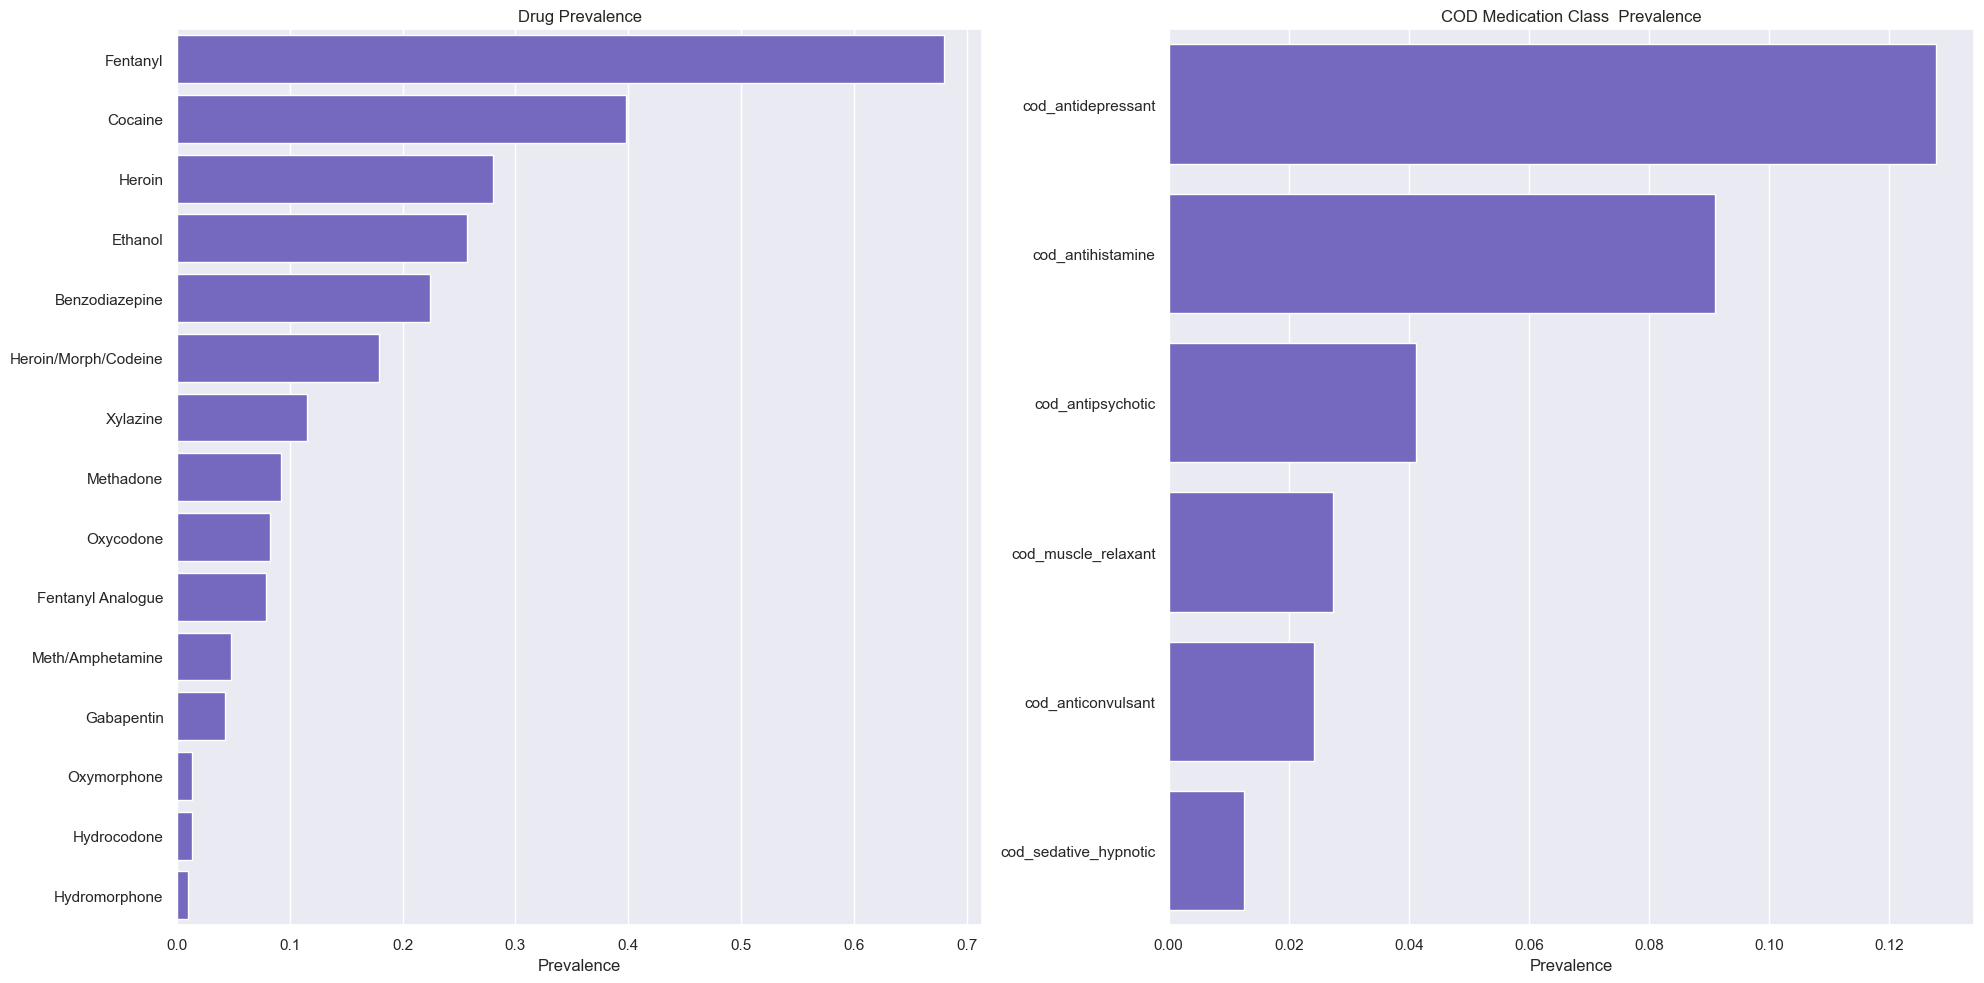

In [38]:
sns.set_theme(style='darkgrid')
sns.set_palette(palette='Set2')

drug_prev = df_clean[drug_cols].mean().sort_values(ascending=False)
cod_prev = df_clean[cod_cols].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

sns.barplot(x=drug_prev.values, y=drug_prev.index, color='slateblue', ax=axes[0])
axes[0].set(title='Drug Prevalence', xlabel='Prevalence', ylabel='')

sns.barplot(x=cod_prev.values, y=cod_prev.index, color='slateblue', ax=axes[1])
axes[1].set(title='COD Medication Class  Prevalence', xlabel='Prevalence', ylabel='')

plt.tight_layout()
plt.show()


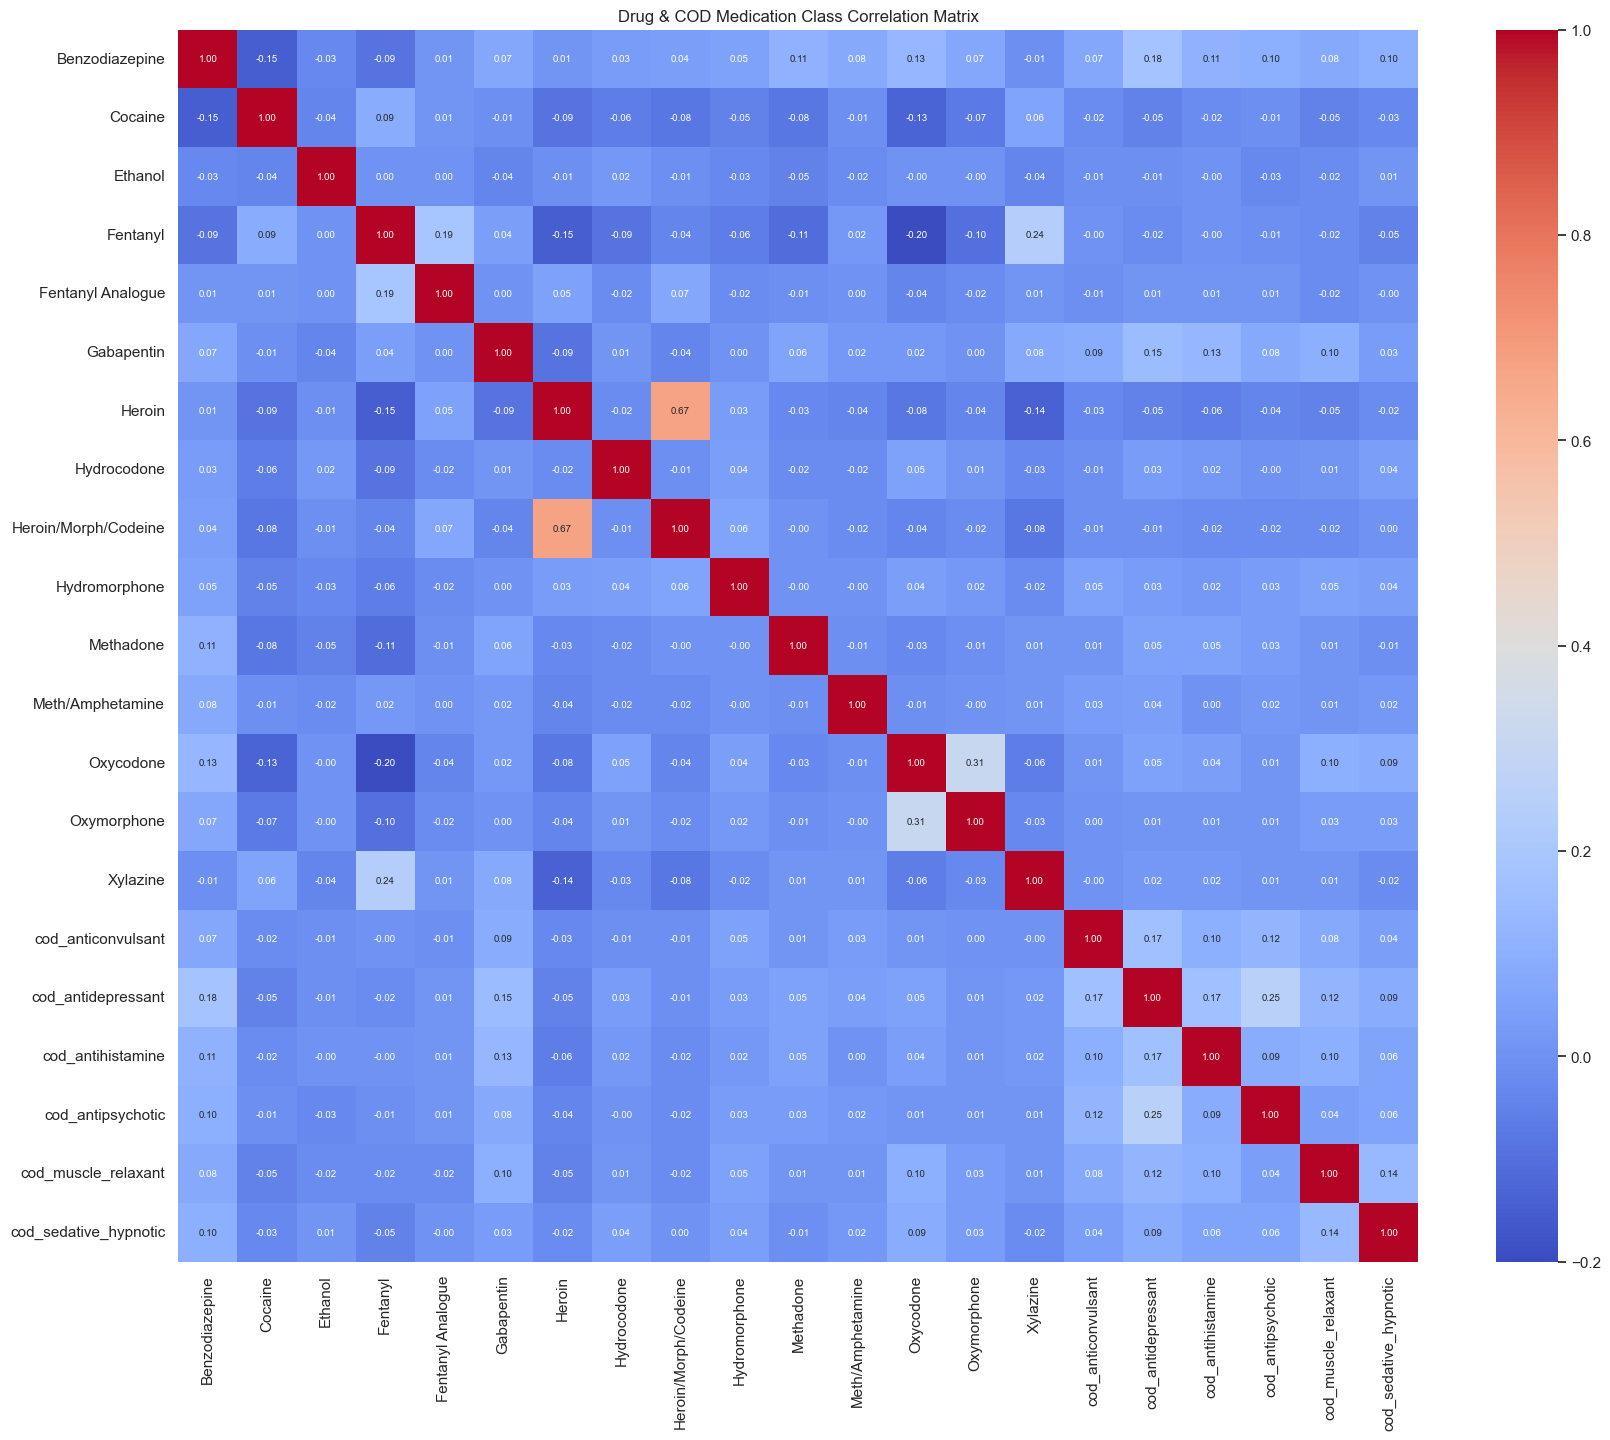

In [39]:
cluster_features = drug_cols + cod_cols
fig, ax = plt.subplots(figsize=(20, 16))
sns.heatmap(df_clean[cluster_features].corr().round(2), 
            annot=True, cmap='coolwarm', fmt='.2f', ax=ax, annot_kws={'size': 7})
ax.set_title('Drug & COD Medication Class Correlation Matrix')

plt.show()

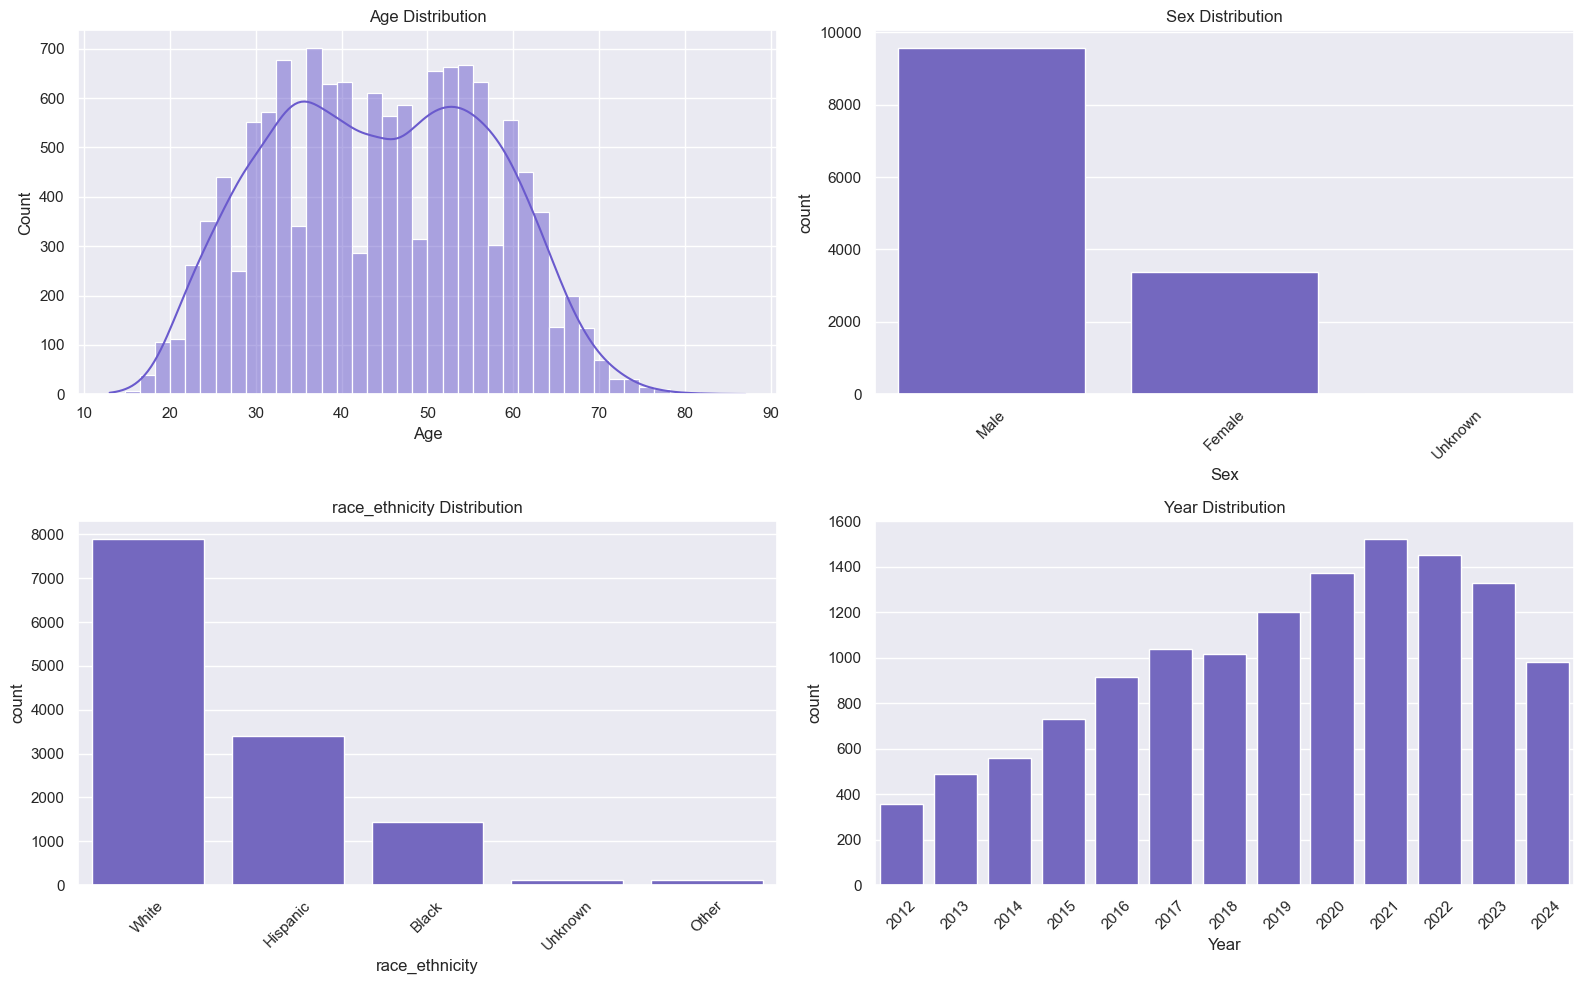

In [40]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(demographics_cols):
    if col == 'Age':
        sns.histplot(df_clean[col].dropna(), kde=True, ax=axes[i], color='slateblue')
    else:
        order = sorted(df_clean[col].unique()) if col == 'Year' else df_clean[col].value_counts().index
        sns.countplot(data=df_clean, x=col, order=order, ax=axes[i], color='slateblue')
        axes[i].tick_params(axis='x', rotation=45)
    axes[i].set(title=f'{col} Distribution')

plt.tight_layout()
plt.show()

## Preprocessing

In [41]:
drugs_21 = df_clean[drug_cols + cod_cols].copy()
drugs_20 = drugs_21.drop('Heroin/Morph/Codeine', axis=1).copy()
drugs_15 = df_clean[drug_cols].copy()
drugs_14 = drugs_15.drop('Heroin/Morph/Codeine', axis=1).copy()

datasets = [drugs_21, drugs_20, drugs_15, drugs_14]

ds_labels = ['Drugs 21', 'Drugs 20', 'Drugs 15', 'Drugs 14']

## Clustering
### Feature Set Selection

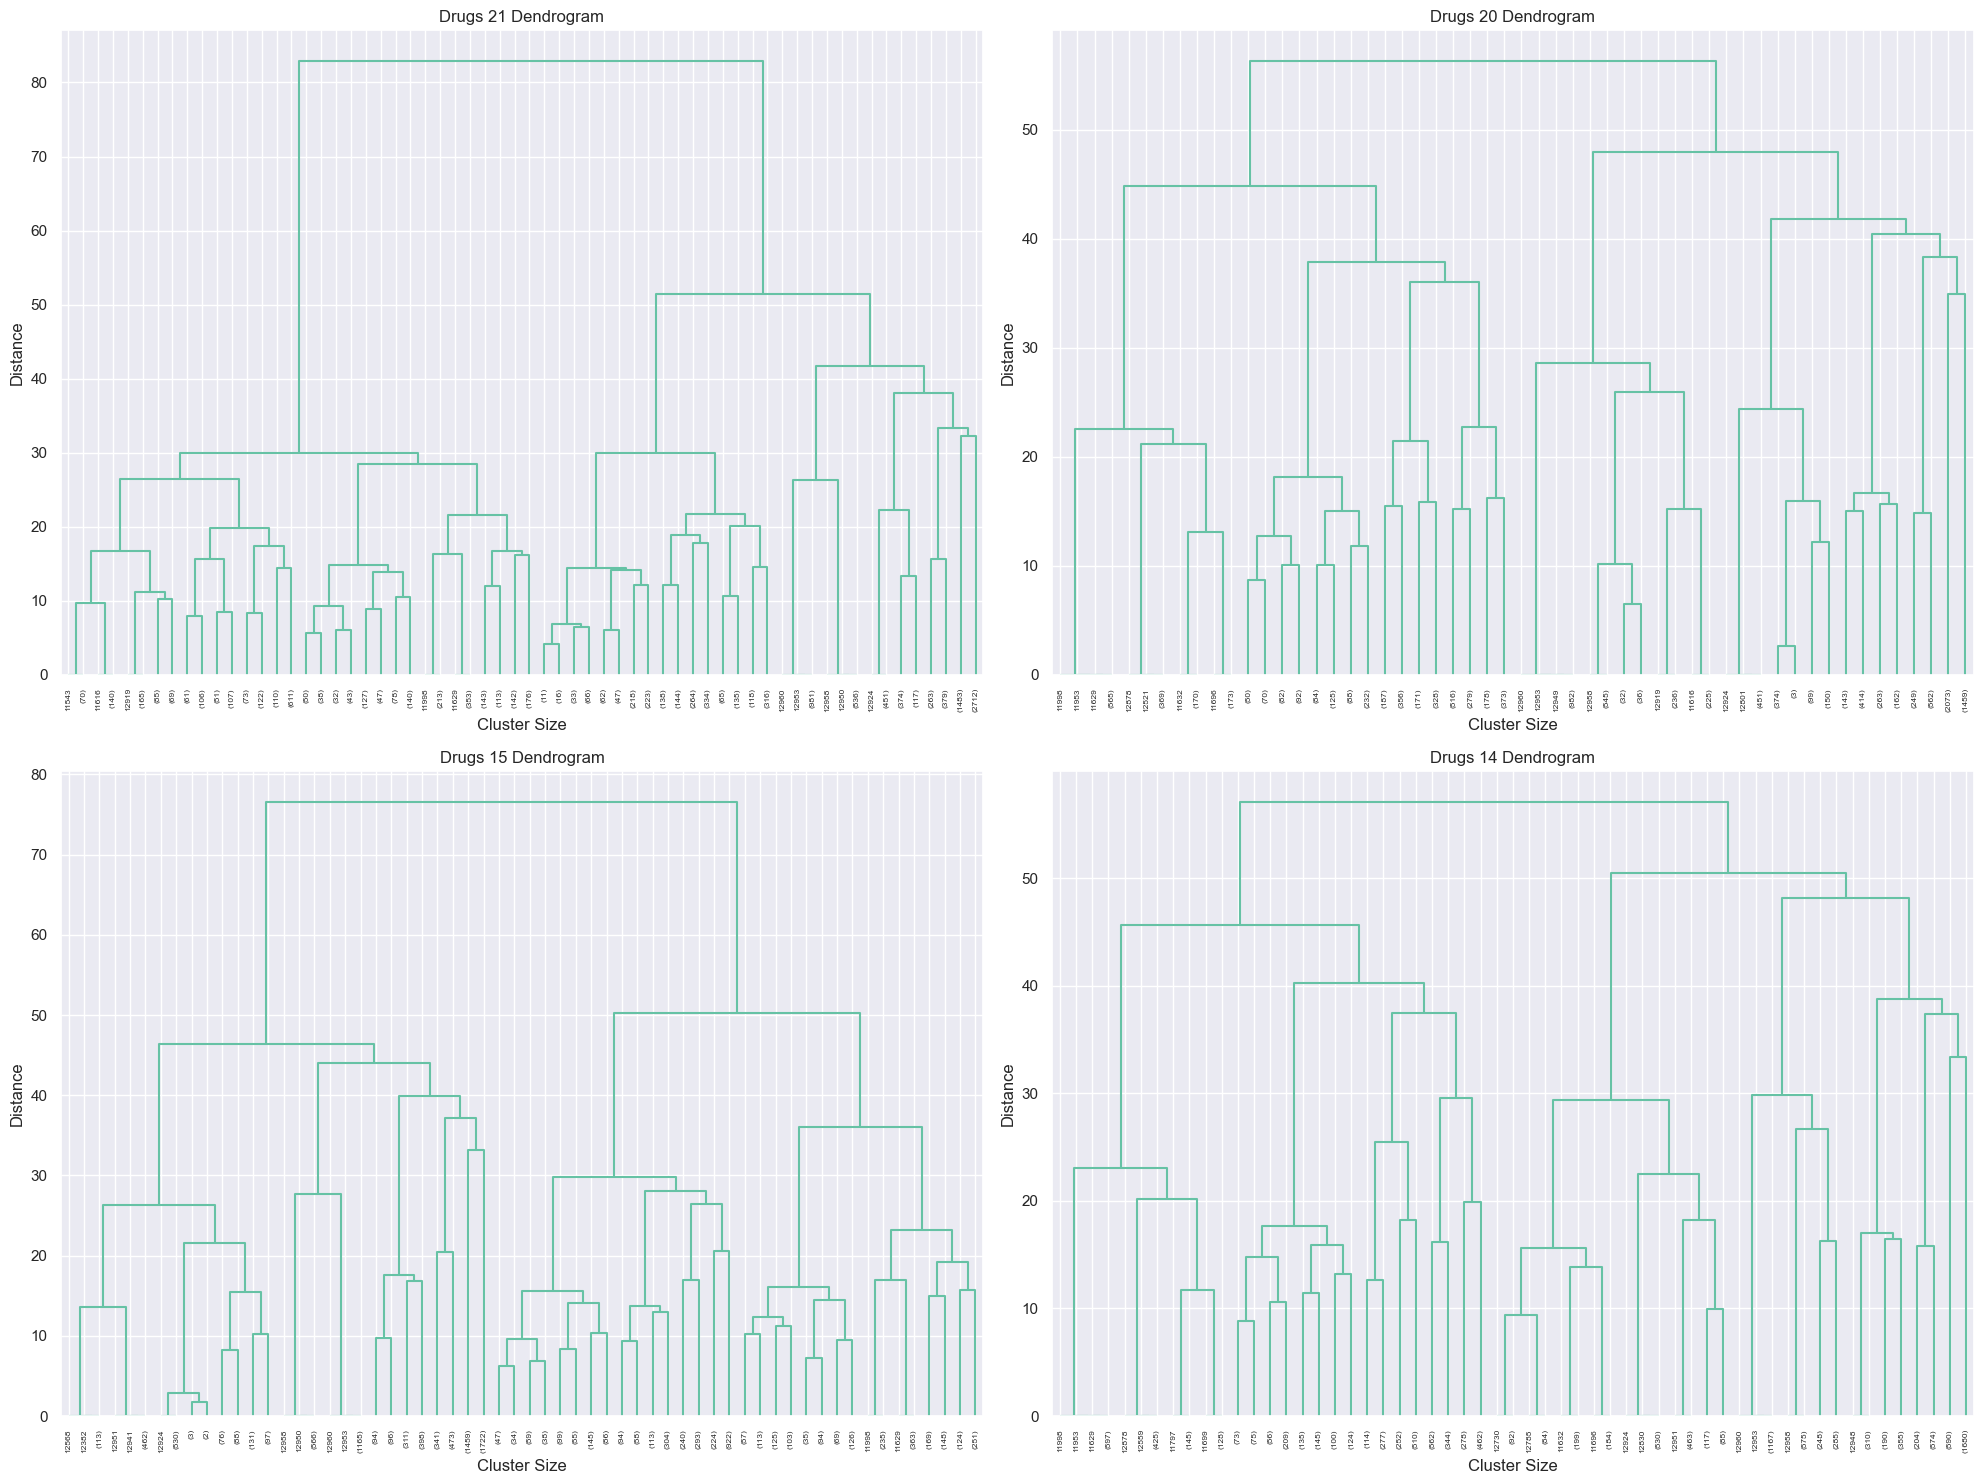

In [42]:
fig, axes = plt.subplots(2, 2, figsize=(20, 15))
axes = axes.flatten()

for i, data in enumerate(datasets):
    linked = linkage(data.values, method='ward')
    dendrogram(linked, truncate_mode='level', p=5, ax=axes[i], color_threshold=0)
    axes[i].set(title=f'{ds_labels[i]} Dendrogram', xlabel='Cluster Size', ylabel='Distance')

plt.tight_layout()
plt.show()

### K-Medoids

In [43]:
K = range(2, 15)
kmed_scores = []

for data in datasets:
    dist = squareform(pdist(data.values, metric='cityblock'))
    s = []
    for k in list(K):
        result = kmedoids.fasterpam(dist, k, random_state=9)
        s.append(silhouette_score(dist, result.labels, metric='precomputed'))
    kmed_scores.append(s)

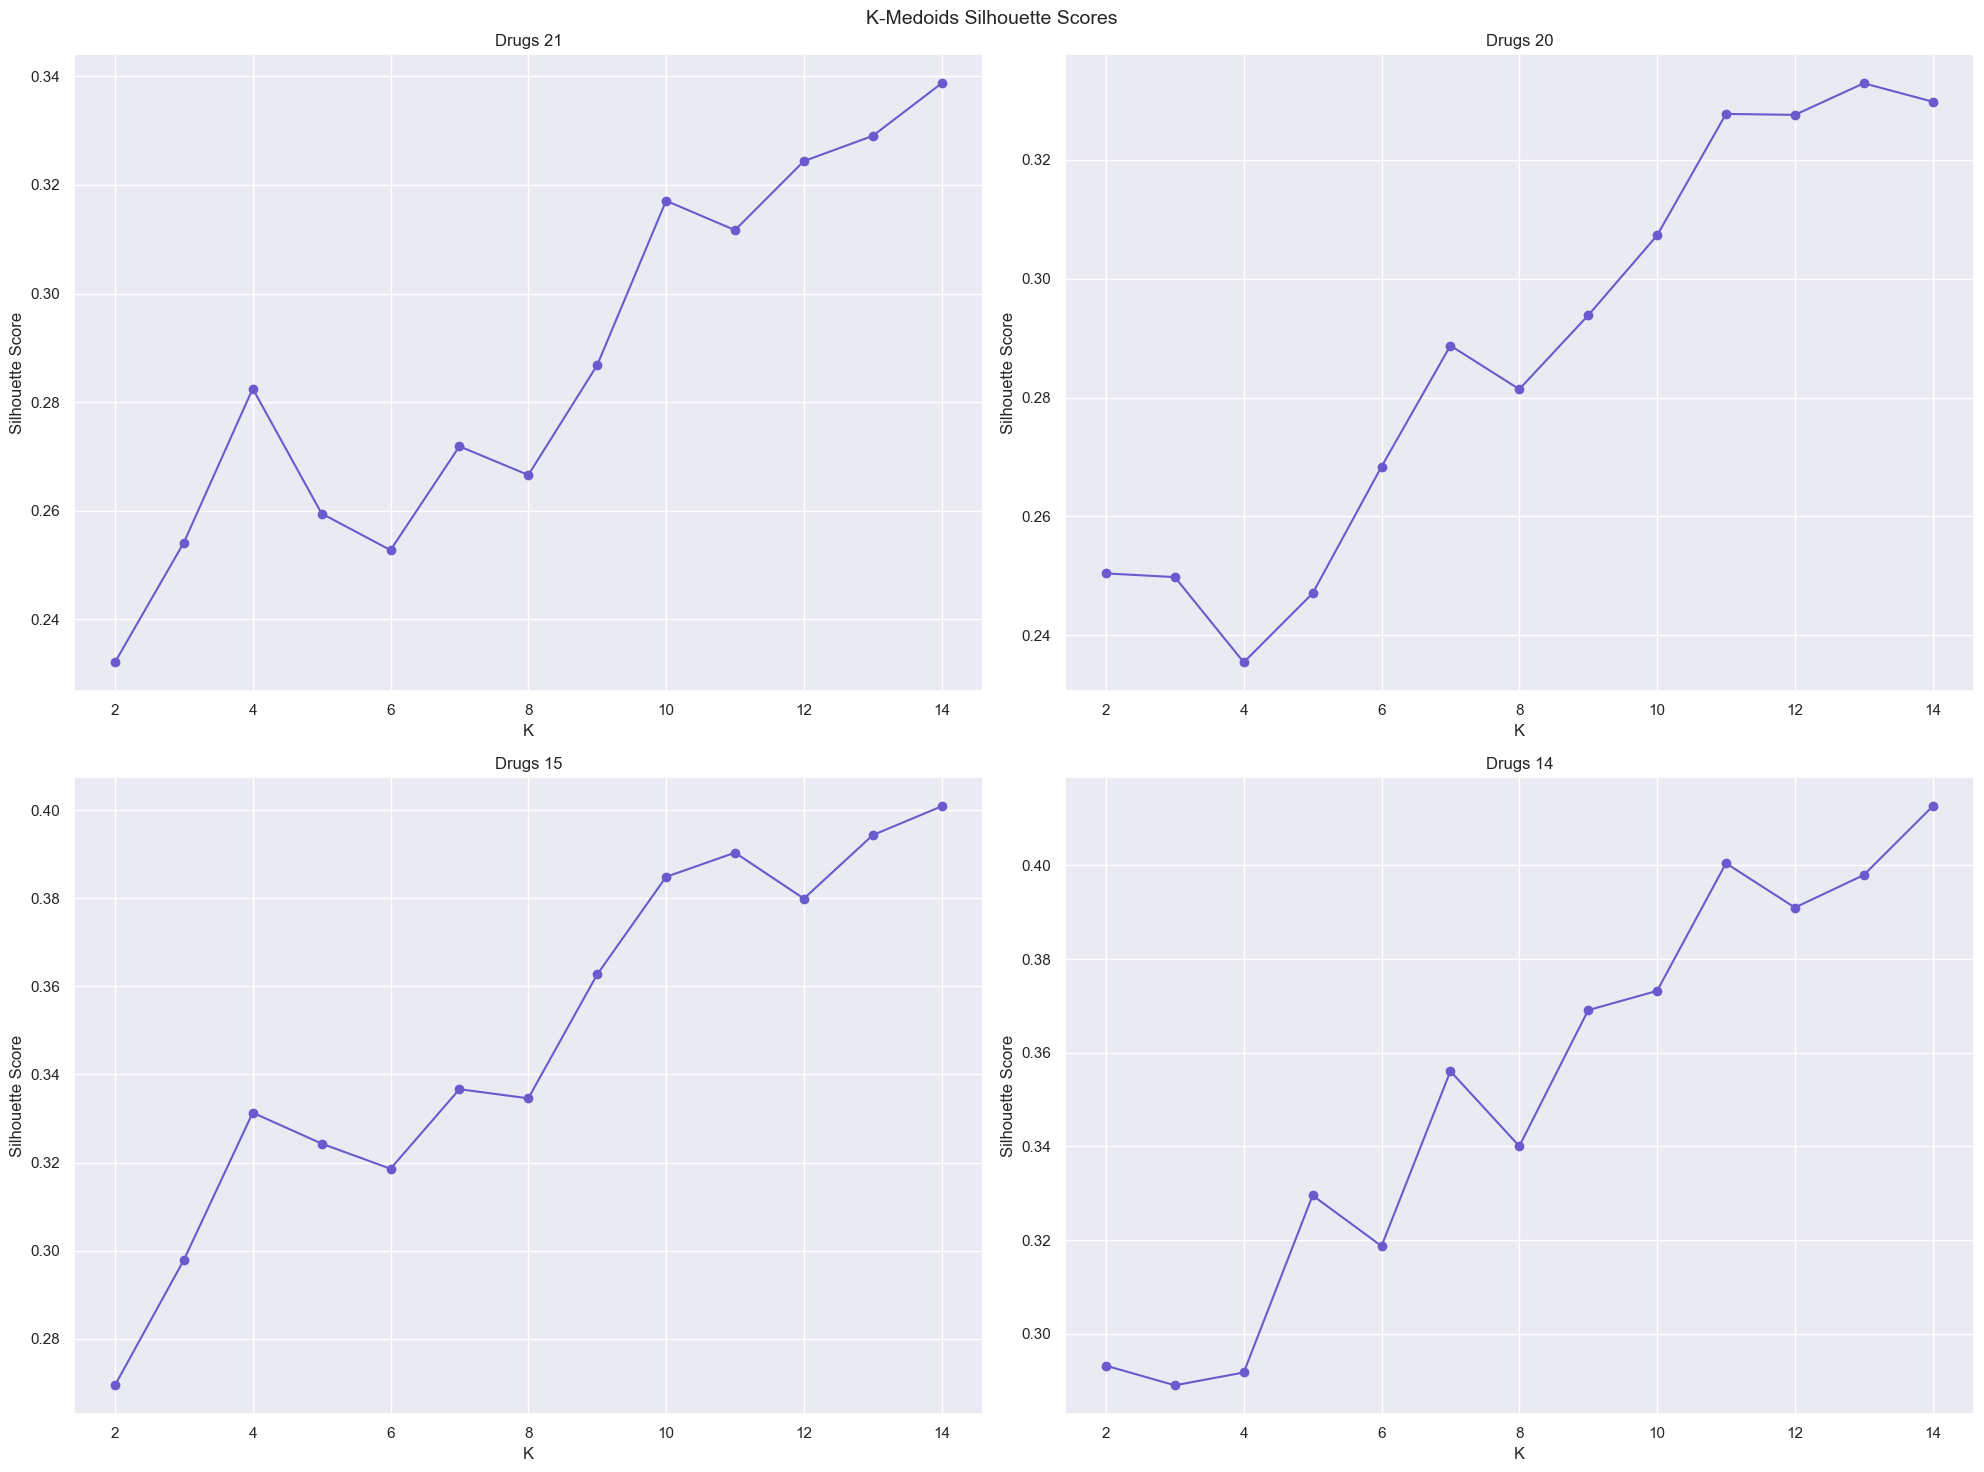

In [44]:
fig, axes = plt.subplots(2, 2, figsize=(20, 15))
axes = axes.flatten()

for i, scores in enumerate(kmed_scores):
    axes[i].plot(list(K), scores, 'o-', color='slateblue')
    axes[i].set(title=f'{ds_labels[i]}', xlabel='K', ylabel='Silhouette Score')

plt.suptitle('K-Medoids Silhouette Scores', fontsize=14)
plt.tight_layout()
plt.show()
    

### K-Modes

In [45]:
kmodes_costs = []
kmodes_scores = []

for data in datasets:
    c = []
    s =  []
    for k in list(K):
        kmode = KModes(n_clusters=k, init='Huang', n_init=50, random_state=9)
        labels = kmode.fit_predict(data.values)
        c.append(kmode.cost_)
        s.append(silhouette_score(data.values, labels, metric='hamming'))
    
    kmodes_costs.append(c)
    kmodes_scores.append(s)

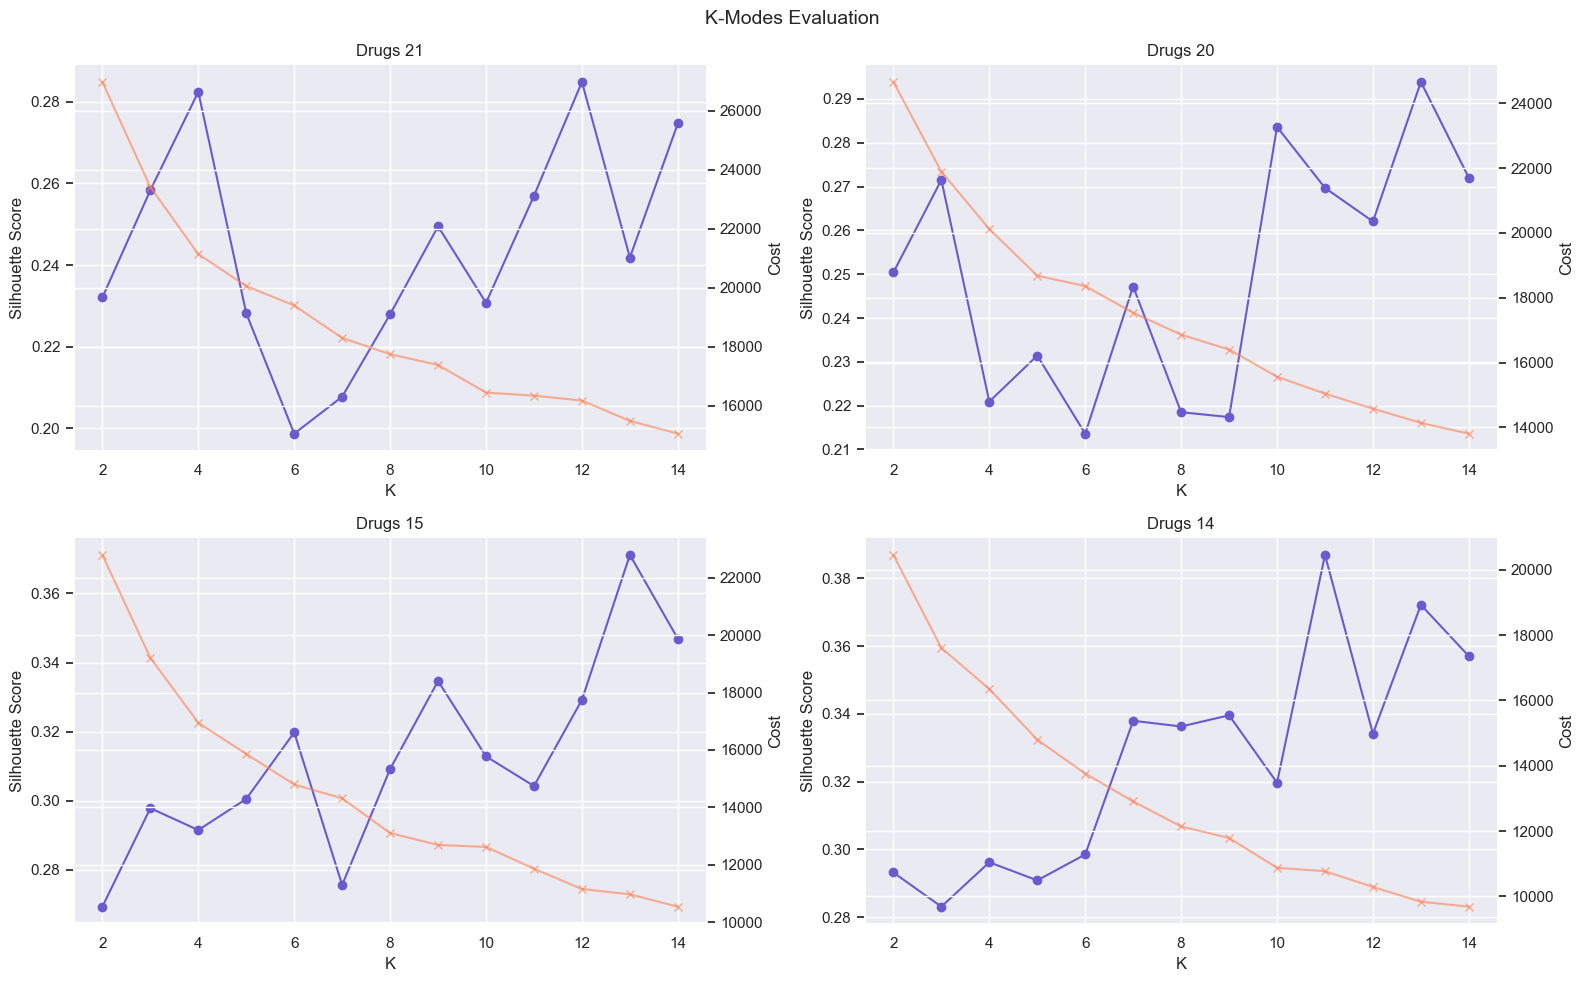

In [46]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, name in enumerate(ds_labels):
    axes[i].plot(list(K), kmodes_scores[i], 'o-', color='slateblue', label='Silhouette')
    ax2 = axes[i].twinx()
    ax2.plot(list(K), kmodes_costs[i], 'x-', color='coral', alpha=0.6, label='Cost')
    axes[i].set(title=name, xlabel='K', ylabel='Silhouette Score')
    ax2.set_ylabel('Cost')

plt.suptitle('K-Modes Evaluation', fontsize=14)
plt.tight_layout()
plt.show()

### Model Selection

In [47]:
for j, k in enumerate(K):
    d = f'{kmed_scores[3][j] - kmed_scores[3][j-1]:+.4f}' if j > 0 else '     -'
    print(f'k={k:2d}  sil={kmed_scores[3][j]:.4f}  {d}')

k= 2  sil=0.2932       -
k= 3  sil=0.2890  -0.0042
k= 4  sil=0.2917  +0.0027
k= 5  sil=0.3296  +0.0378
k= 6  sil=0.3187  -0.0108
k= 7  sil=0.3561  +0.0373
k= 8  sil=0.3401  -0.0160
k= 9  sil=0.3691  +0.0290
k=10  sil=0.3732  +0.0041
k=11  sil=0.4005  +0.0273
k=12  sil=0.3910  -0.0095
k=13  sil=0.3980  +0.0069
k=14  sil=0.4126  +0.0147


In [48]:
dist_14 = squareform(pdist(drugs_14.values, metric='cityblock'))
final_model = kmedoids.fasterpam(dist_14, 10, random_state=9)

cluster_names = {
    0: 'Fentanyl',
    1: 'Benzodiazepines & RX Opioids',
    2: 'Mixed Low Ethanol & RX Opioids',
    3: 'Heroin',
    4: 'Heroin & Fentanyl',
    5: 'Cocaine',
    6: 'Ethanol & Fentanyl',
    7: 'Cocaine & Fentanyl',
    8: 'Cocaine Ethanol Fentanyl',
    9: 'Benzodiazepines & Fentanyl'
}

df_clean['cluster'] = final_model.labels
df_clean['cluster_name'] = df_clean['cluster'].map(cluster_names)

df_clean['cluster_name'].value_counts()

cluster_name
Cocaine & Fentanyl                2266
Fentanyl                          2071
Heroin & Fentanyl                 1912
Heroin                            1561
Cocaine                            947
Cocaine Ethanol Fentanyl           935
Mixed Low Ethanol & RX Opioids     893
Ethanol & Fentanyl                 819
Benzodiazepines & Fentanyl         807
Benzodiazepines & RX Opioids       750
Name: count, dtype: int64

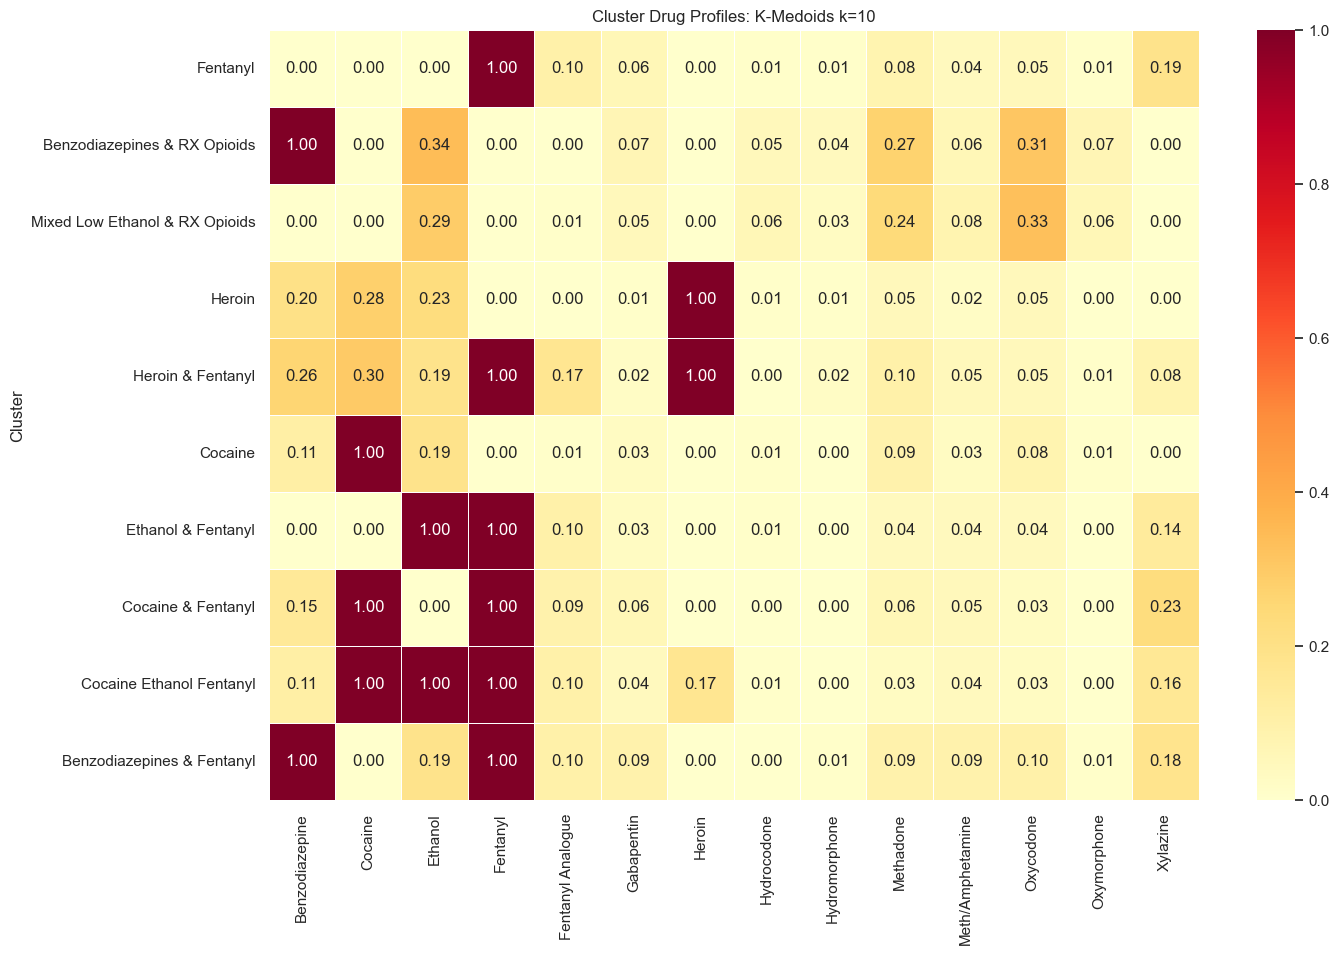

In [49]:
cluster_profiles = drugs_14.copy()
cluster_profiles['Cluster'] = final_model.labels
cluster_profiles = cluster_profiles.groupby('Cluster').mean()
cluster_profiles.index = cluster_profiles.index.map(cluster_names)

fig, ax = plt.subplots(figsize=(15, 10))
sns.heatmap(cluster_profiles.round(2), annot=True, fmt='.2f', cmap='YlOrRd', ax=ax, linewidth=0.5, vmin=0, vmax=1)
ax.set_title('Cluster Drug Profiles: K-Medoids k=10')
plt.show()

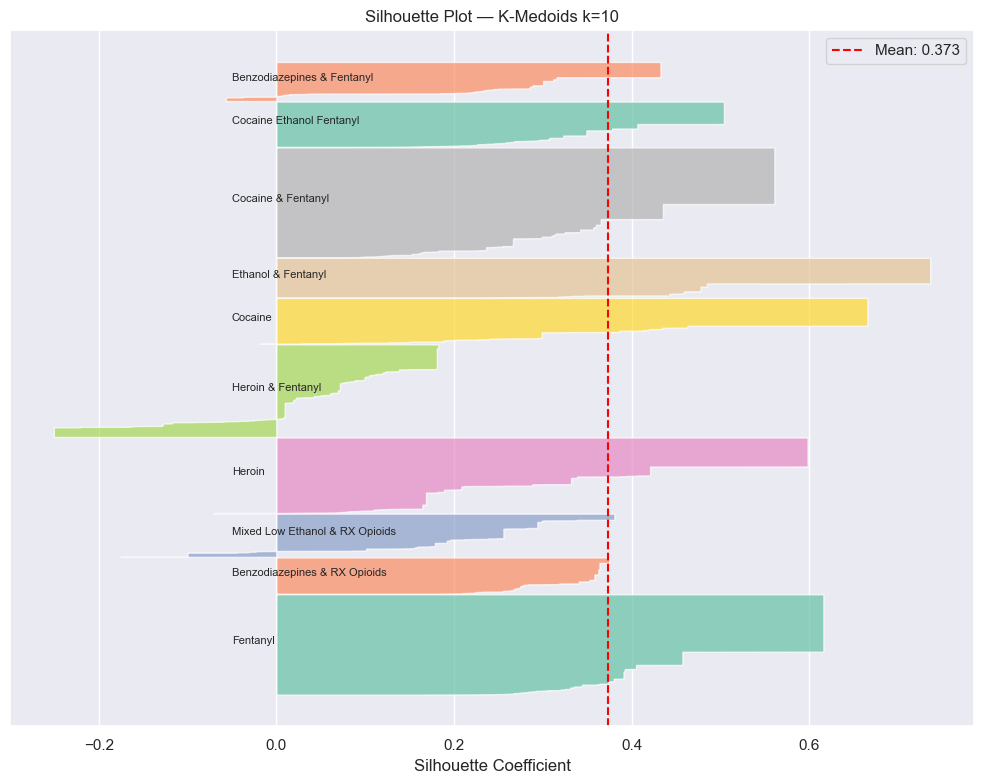

In [50]:
sil_vals = silhouette_samples(dist_14, final_model.labels, metric='precomputed')
sil_avg = sil_vals.mean()

fig, ax = plt.subplots(figsize=(10, 8))
y_lower = 0

for c in range(10):
    cluster_sils = np.sort(sil_vals[final_model.labels == c])
    y_upper = y_lower + len(cluster_sils)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sils, alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * len(cluster_sils), cluster_names[c], fontsize=8)
    y_lower = y_upper + 10

ax.axvline(sil_avg, color='red', linestyle='--', label=f'Mean: {sil_avg:.3f}')
ax.set(title='Silhouette Plot — K-Medoids k=10', xlabel='Silhouette Coefficient', ylabel='')
ax.set_yticks([])
ax.legend()
plt.tight_layout()
plt.show()

## Cluster Profiling

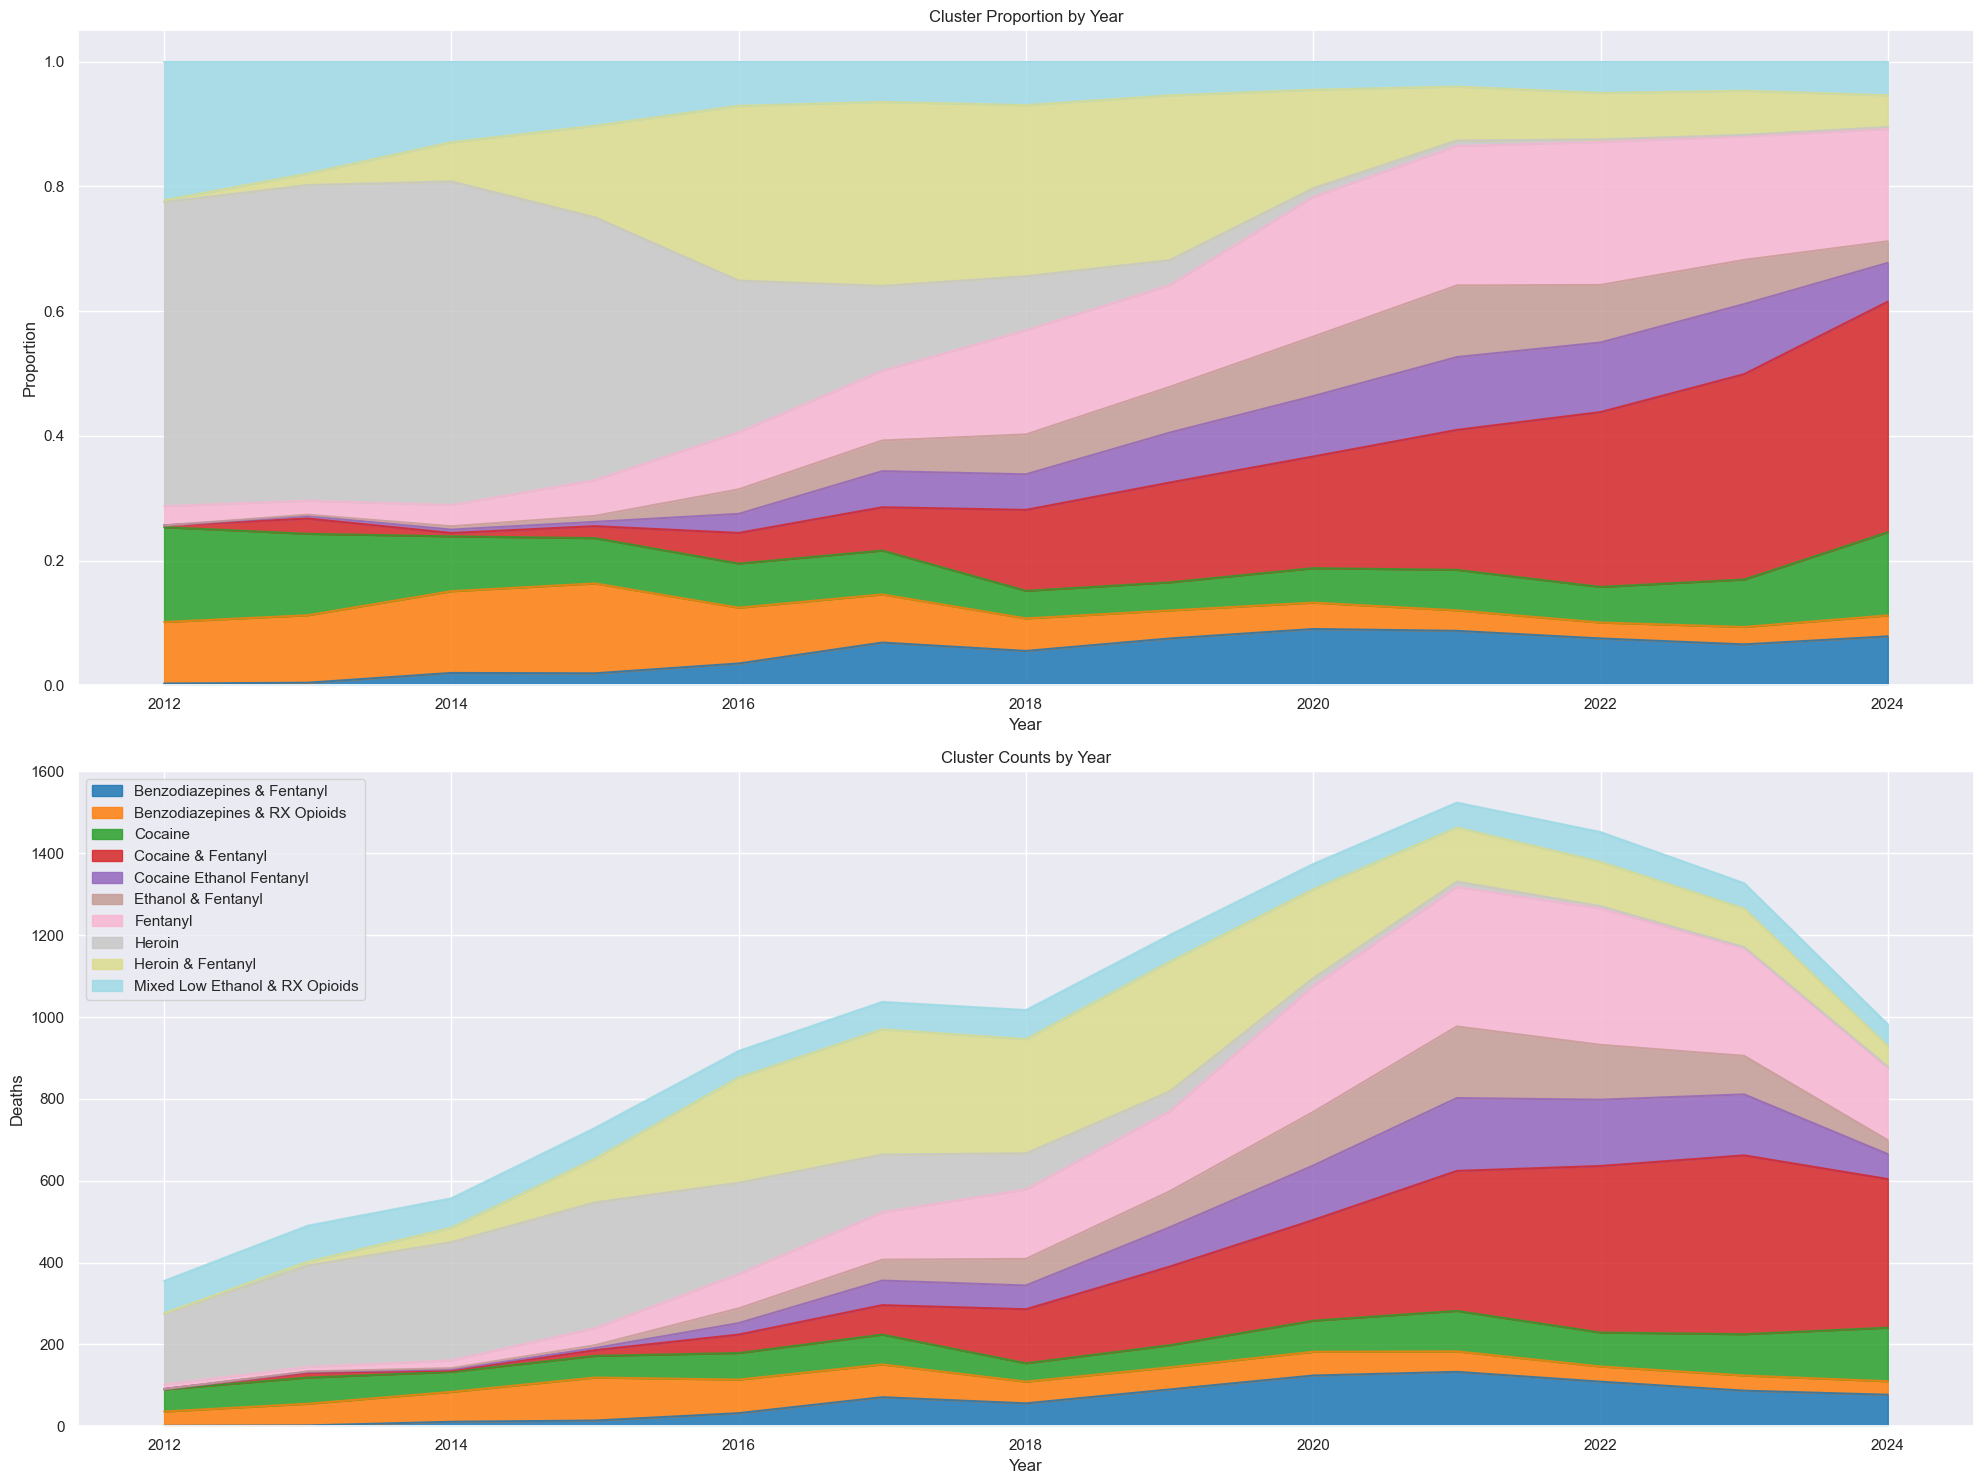

In [51]:
year_ct = pd.crosstab(df_clean['Year'], df_clean['cluster_name'])

fig, axes = plt.subplots(2, 1, figsize=(20, 15))

year_ct.div(year_ct.sum(axis=1), axis=0).plot(kind='area', stacked=True, ax=axes[0], colormap='tab20', alpha=0.85, legend=False)
axes[0].set(title='Cluster Proportion by Year', ylabel='Proportion', xlabel='Year')

year_ct.plot(kind='area', stacked=True, ax=axes[1], colormap='tab20', alpha=0.85)
axes[1].set(title='Cluster Counts by Year', ylabel='Deaths', xlabel='Year')
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.show()

### Demographics

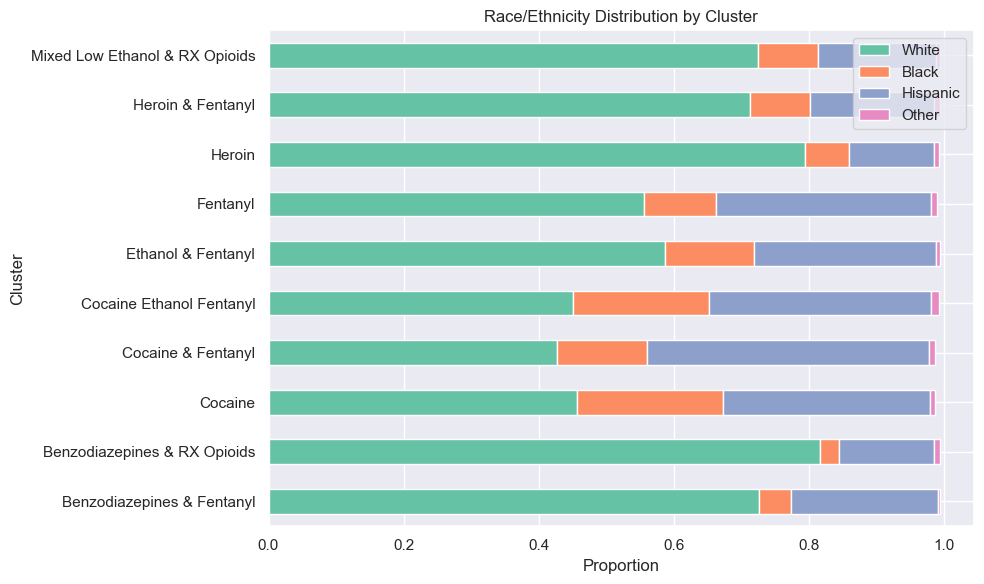

In [52]:
race_ct = pd.crosstab(df_clean['cluster_name'], df_clean['race_ethnicity'], normalize='index')
race_ct.plot(y=['White', 'Black', 'Hispanic', 'Other'], kind='barh', stacked=True, figsize=(10, 6))

plt.legend(loc='upper right')
plt.xlabel('Proportion')
plt.ylabel('Cluster')
plt.title('Race/Ethnicity Distribution by Cluster')
plt.xticks()
plt.tight_layout()
plt.show()


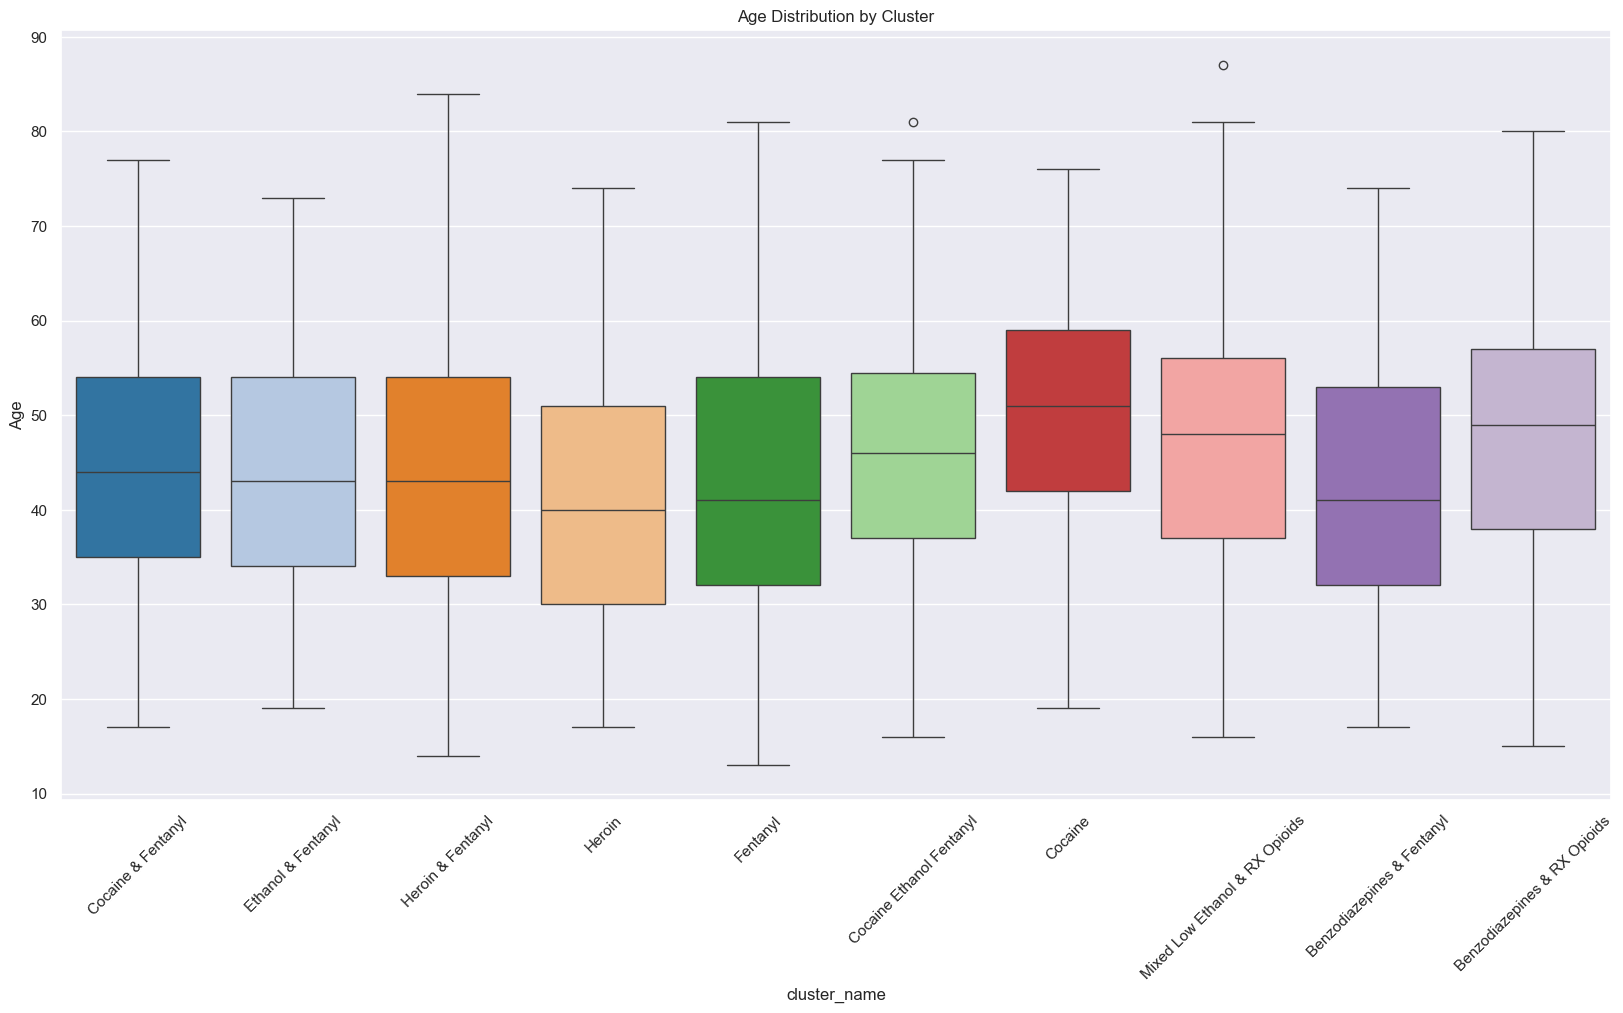

In [53]:
fig, ax = plt.subplots(figsize = (20, 10))

sns.boxplot(df_clean, x='cluster_name', y='Age', hue='cluster_name', palette='tab20')
ax.set(title='Age Distribution by Cluster', ylabel='Age')
ax.tick_params(axis='x', labelrotation=45)

plt.show()

### Profiles

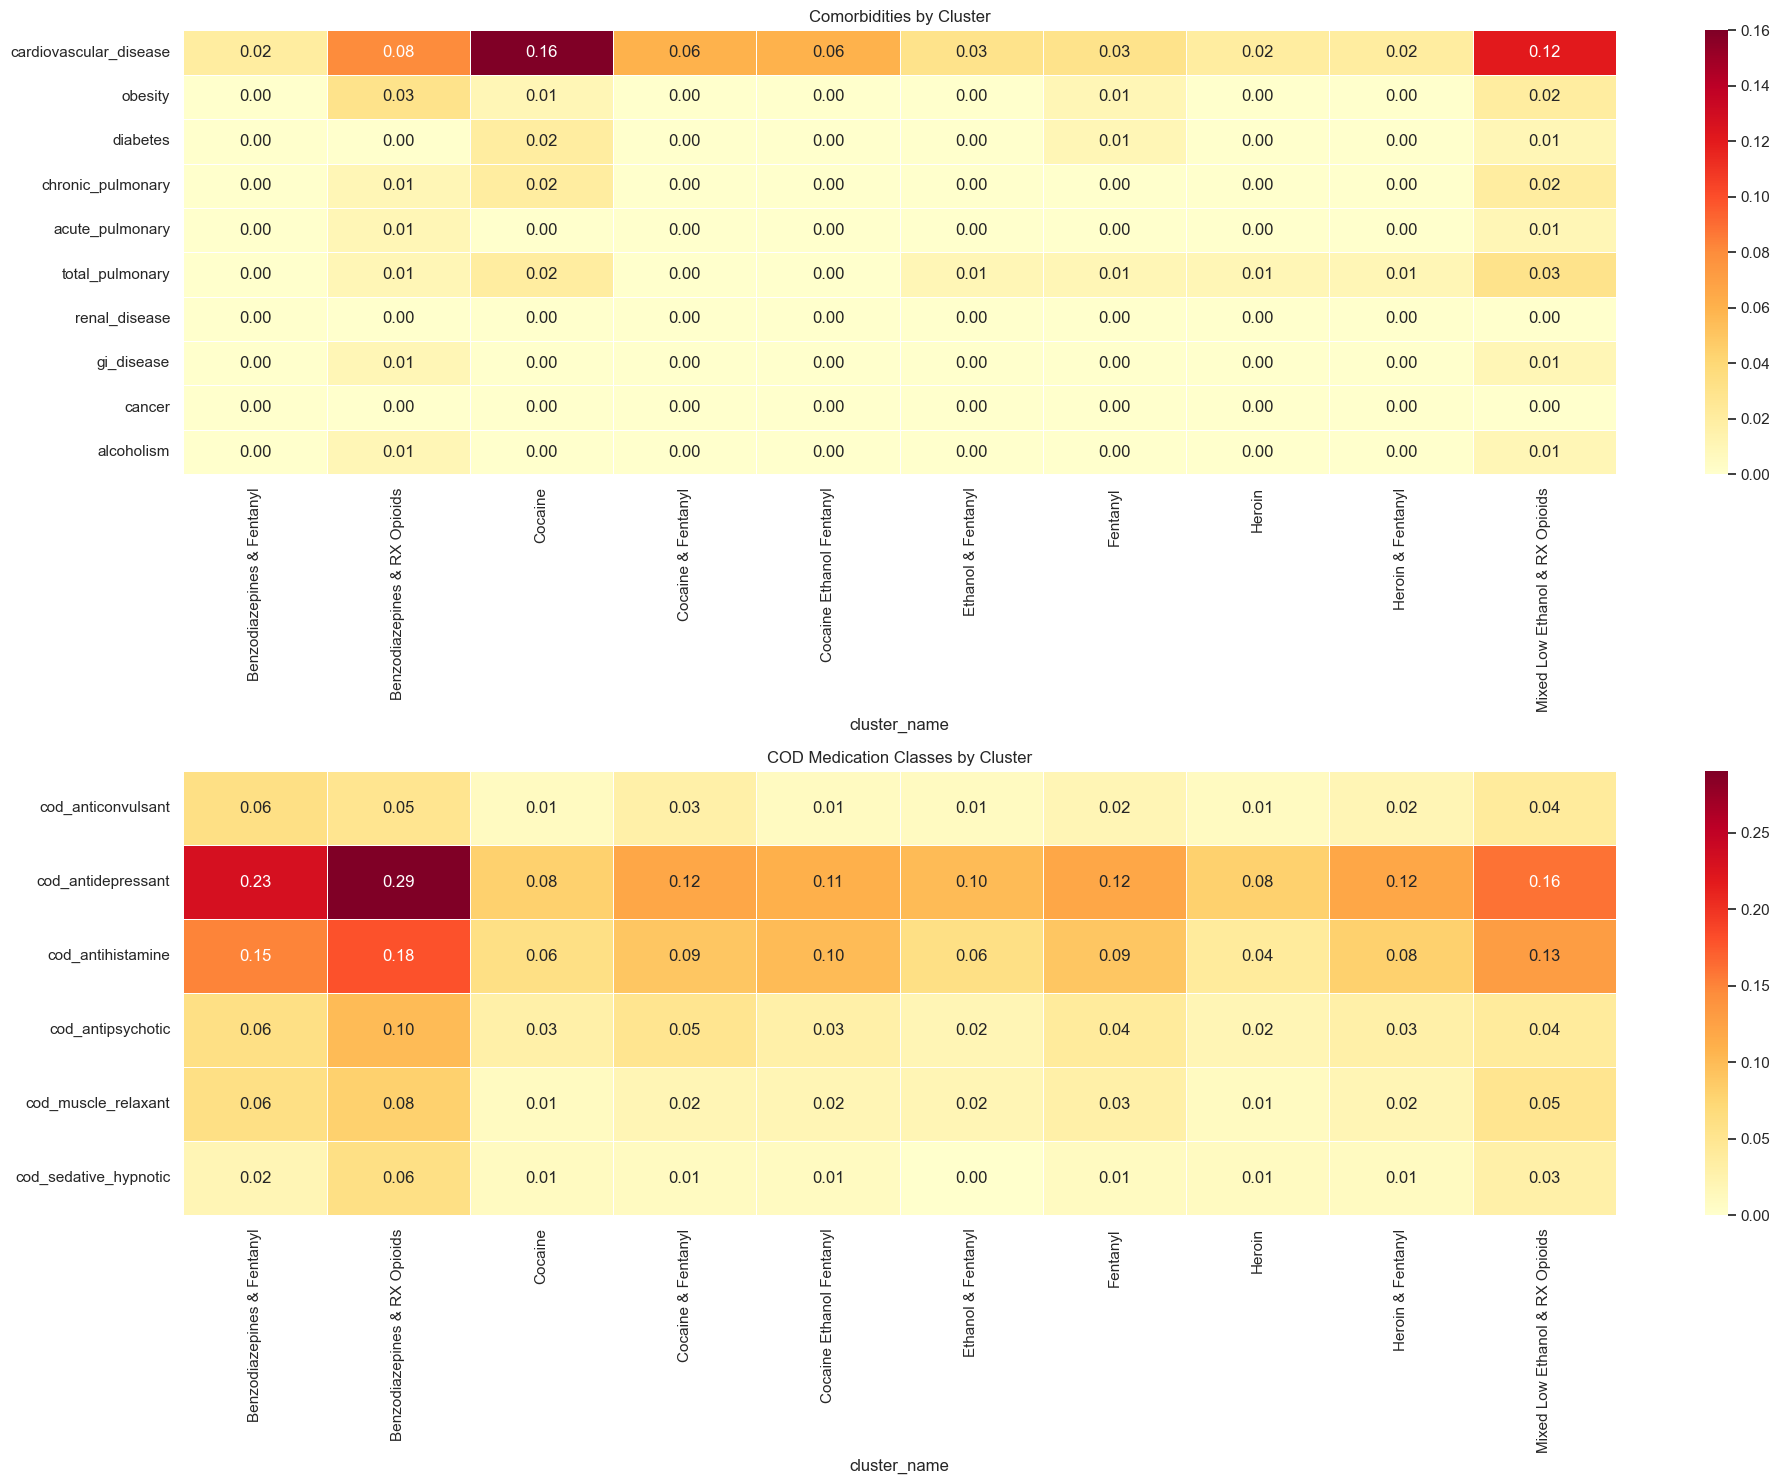

In [54]:
fig, axes = plt.subplots(2, 1, figsize = (20, 15))

comorbid_means = df_clean.groupby('cluster_name')[comorbidities].mean()
sns.heatmap(comorbid_means.round(2).T, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[0], linewidths=0.5, vmin=0)
axes[0].set_title('Comorbidities by Cluster')

cod_means = df_clean.groupby('cluster_name')[cod_cols].mean()
sns.heatmap(cod_means.round(2).T, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[1], linewidth=0.5)
axes[1].set_title('COD Medication Classes by Cluster')

plt.tight_layout()
plt.show()